# LFP phase-coherence diagnostics & parameter sweeps (DIV 12)

Single event per well (cheap) to probe the sensitivity of the spatial phase-coherence result:
1. **Phase vs power** — unit-phasor `<cos Δφ>` (all channels equal) vs amplitude-weighted **coherency**
   (silent channels down-weighted continuously; no threshold).
2. **Temporal dynamics** — coherence-over-distance resolved *through* the burst, `C(r, t)`.
3. **Distance-binning** and **averaging-window** sweeps.

Reuses the shared `ephax.metrics.event_selection` backend so the event set matches the main notebooks.
The expensive filtering runs **once per event** (a phasor bank); every analysis re-derives from it.

In [21]:
%matplotlib inline

import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.metrics.lfp import (
    bandpass_downsample,
    dataset_for_well,
    extract_phasors,
    inspect_file,
    load_chunk,
    load_data_store_spikes,
)
from ephax.metrics.event_selection import (
    LFPWavefrontCacheConfig,
    LFPEventFrontBuildConfig,
    WellBurstConfig,
    FrontNullConfig,
    ensure_lfp_wavefront_caches,
    load_all_wavefront_caches,
    detect_well_bursts,
    peri_anchor_spike_counts,
    compute_front_null_support,
    front_significant_events,
)
from ephax.plotting import PAPER_COLORS, apply_paper_style
from ephax.plotting.style import LINE_WIDTHS, FONT_SIZES

apply_paper_style()
plt.rcParams["figure.dpi"] = 150
np.random.seed(0)

In [ ]:
DIV = 12
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
EXAMPLE_WELL = 0
CACHE_PROFILE = "confirm"
LFP_SOURCE = "stim_removal_null_lfp"
BAND_LABEL = "30-50 Hz"
FS_DS = 500.0
SAVE_FIGURE = True
BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 0
NULL_CORRECTION_ENABLED = True
NULL_CORRECTION_FORCE_RECOMPUTE = False
NULL_CORRECTION_REPS = 30
NULL_CORRECTION_SEED = 1
NULL_CORRECTION_TYPES = ["coordinate_shuffle", "arrival_time_shuffle"]
NULL_CORRECTION_MAX_EVENTS_PER_WELL = 25
NULL_FRONT_RADIUS_MM = 0.30
NULL_FRONT_MIN_NEIGHBORS = 8
NULL_FRONT_MAX_RADIUS_MM = 0.45
NULL_FRONT_MAX_NEIGHBORS = 24
NULL_FRONT_MIN_GEOMETRY_RATIO = 0.10
NULL_FRONT_MATCH_MAX_MS = 8.0
NULL_FRONT_MAX_RESIDUAL_MS = 4.0
NULL_FRONT_MIN_ARRIVAL_SPAN_MS = 1.0
NULL_FRONT_MIN_DISTANCE_SPAN_MM = 0.20
NULL_FRONT_MAX_SPEED_MM_PER_S = 500.0
SPEED_PANEL_MODE = "null_corrected"  # "null_corrected" or "all_qc_valid"
LFP_DIAGNOSTIC_PAD_S = 0.05
LFP_FILTER_CONTEXT_PAD_S = 0.25
TRACE_EXAMPLE_CHANNELS = 30
TRACE_EXAMPLE_GAIN = 8.0
SNAPSHOT_HEX_GRIDSIZE = 35
SNAPSHOT_HEX_MIN_VECTOR_COUNT = 3
SNAPSHOT_VECTOR_SCALE_MS = 2.2
SNAPSHOT_VECTOR_MAX_MM = 0.20
PHASE_COH_FREQ_LOW_HZ = 1.0
PHASE_COH_FREQ_HIGH_HZ = 100.0
PHASE_COH_N_BANDS = 50
PHASE_COH_REL_BANDWIDTH = 0.18
PHASE_COH_USE_ALL_CHANNELS = True
PHASE_COH_MAX_CHANNELS = None
TRACE_EXAMPLE_EVENT_IDX = None  # None selects the well-0 event with most valid local fits
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

STIM_REMOVAL_NULL_LFP_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull") / f"DIV {int(DIV)}" / "data.raw.h5"
WAVE_CACHE_DIR = repo_root / "outputs" / "lfp_waves"
OUTPUT_DIR = repo_root / "outputs" / "figure3_lfp_event_front"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_NOTE = "Cached confirm burst-front screen, 30-50 Hz, 500 Hz"
FIGURE3_PRIMARY_COLOR = PAPER_COLORS["ephaptic_axonal"]
FIGURE3_PRIMARY_LIGHT = "#ead6f6"
FIGURE3_ACCENT_COLOR = PAPER_COLORS["highlight"]
FIGURE3_BURST_COLOR = PAPER_COLORS["burst"]


wavefront_cache_config = LFPWavefrontCacheConfig(
    source=LFP_SOURCE,
    profile=CACHE_PROFILE,
    div=DIV,
    band_low_hz=30.0,
    band_high_hz=50.0,
    fs_hz=FS_DS,
    lambda_min_mm=0.5,
    lambda_max_mm=10.0,
    radial=True,
    interval_mode="burst",
)

cache_paths = ensure_lfp_wavefront_caches(LFPEventFrontBuildConfig(
    raw_file=STIM_REMOVAL_NULL_LFP_FILE,
    cache_dir=WAVE_CACHE_DIR,
    cache=wavefront_cache_config,
    wells=tuple(AGGREGATE_WELLS),
    profile_calibration_events=None if CACHE_PROFILE == "confirm" else 25,
    profile_scoring_events=200 if CACHE_PROFILE == "confirm" else 15,
    min_amp=MIN_AMP,
    top_start=TOP_START,
    top_stop=TOP_STOP,
    ifr_grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    highres_bin_ms=HIGHRES_BIN_MS,
    highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
    phase_pad_s=LFP_FILTER_CONTEXT_PAD_S,
    search_pre_ms=20.0,
    search_post_ms=40.0,
    match_max_ms=NULL_FRONT_MATCH_MAX_MS,
    radius_mm=NULL_FRONT_RADIUS_MM,
    min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
    max_radius_mm=NULL_FRONT_MAX_RADIUS_MM,
    max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
    min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO,
    max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS,
    min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
    min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM,
    max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
), build_missing=True)
AGGREGATE_WELLS = sorted(cache_paths)

if int(EXAMPLE_WELL) not in cache_paths:
    EXAMPLE_WELL = int(sorted(cache_paths)[0])
    print(f"EXAMPLE_WELL was unavailable; using well {EXAMPLE_WELL}.")

cache_manifest_df = pd.DataFrame([
    {"well": well, "cache_path": str(path), "cache_name": path.name}
    for well, path in sorted(cache_paths.items())
])
display(cache_manifest_df)
cache_paths


,well,cache_path,cache_name
0,0,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well0_...
1,1,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well1_...
2,2,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well2_...
3,3,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well3_...
4,4,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well4_...
5,5,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well5_...


{0: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well0_DIV12_data0000_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 1: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well1_DIV12_data0001_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 2: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well2_DIV12_data0002_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 3: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well3_DIV12_data0003_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 4: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well4_DIV12_data0004_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 5: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wave

In [23]:
# Radial-distance-disaggregated phase-coherence settings (pairwise-separation C(r))
PHASE_COH_DIST_N_BINS = 24        # number of linear electrode-separation bins
PHASE_COH_DIST_MAX_MM = None      # None -> auto from the maximum pairwise distance
PHASE_COH_DIST_MIN_PAIRS = 20     # distance bins with fewer pairs are masked (NaN)

In [24]:
calibration_df, calibration_summary_df, event_df, local_df = load_all_wavefront_caches(cache_paths)

local_df["valid"] = local_df["valid"].astype(bool)
valid_local_df = local_df.loc[local_df["valid"] & np.isfinite(local_df["speed_mm_per_s"])].copy()
event_speed_df = (
    valid_local_df.groupby(["well", "event_idx"], as_index=False)
    .agg(
        median_speed_mm_per_s=("speed_mm_per_s", "median"),
        mean_speed_mm_per_s=("speed_mm_per_s", "mean"),
        n_valid_local_fits=("speed_mm_per_s", "size"),
    )
)
print(f"Loaded {len(event_df)} events, {len(valid_local_df)} QC-valid local fits, {len(event_speed_df)} event medians.")

Loaded 1064 events, 536097 QC-valid local fits, 1064 event medians.


## Shared event selection: null-corrected front-significant events

Same backend call as figure 3 (`compute_front_null_support` + `front_significant_events`), so the
event set is identical by construction (same `local_df`, params and seed).

In [25]:
_front_null_cfg = FrontNullConfig(
    radius_mm=NULL_FRONT_RADIUS_MM, min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
    max_radius_mm=NULL_FRONT_MAX_RADIUS_MM, max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
    min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO, match_max_ms=NULL_FRONT_MATCH_MAX_MS,
    max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS, min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
    min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM, max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
)
front_null_df = compute_front_null_support(
    local_df, event_speed_df,
    null_types=NULL_CORRECTION_TYPES, reps=NULL_CORRECTION_REPS, seed=NULL_CORRECTION_SEED,
    max_events_per_well=NULL_CORRECTION_MAX_EVENTS_PER_WELL, cfg=_front_null_cfg,
    cache_path=OUTPUT_DIR / "tables" / f"spatial_null_support_DIV{int(DIV)}.csv",
    force_recompute=NULL_CORRECTION_FORCE_RECOMPUTE,
)
_corrected = front_significant_events(event_speed_df, front_null_df, support_quantile=0.95)
null_corrected_event_speed_df = _corrected.loc[
    _corrected["front_significant"].astype(bool) & np.isfinite(_corrected["median_speed_mm_per_s"])
].copy()
speed_panel_event_df = null_corrected_event_speed_df
_well_medians = null_corrected_event_speed_df.groupby("well")["median_speed_mm_per_s"].median()
speed_panel_hierarchical_summary = {"median_mm_per_s": float(_well_medians.median())}
print(f"Front-significant events: {len(null_corrected_event_speed_df)} across "
      f"{null_corrected_event_speed_df['well'].nunique()} wells; "
      f"v_eph (hierarchical median) = {speed_panel_hierarchical_summary['median_mm_per_s'] / 1000.0:.3f} mm/ms")

Front-significant events: 115 across 6 wells; v_eph (hierarchical median) = 0.084 mm/ms


In [26]:
WELL_BURST_CFG = WellBurstConfig(
    min_amp=MIN_AMP, top_start=TOP_START, top_stop=TOP_STOP,
    ifr_grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    highres_bin_ms=HIGHRES_BIN_MS, highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
)


def detect_example_well_bursts(well):
    return detect_well_bursts(STIM_REMOVAL_NULL_LFP_FILE, dataset_for_well(well), cfg=WELL_BURST_CFG,
                              cache_dir=OUTPUT_DIR / "burst_cache")

## Diagnostics setup: phasor bank + coherence estimators

In [27]:
from scipy.optimize import curve_fit
from scipy.stats import chi2 as _chi2_dist

DIAG_DISPLAY_PAD_S = 0.15         # display half-window around core (for time-resolved C(r,t))
DIAG_MIN_PAIRS = 50
DIAG_DIST_MAX_MM = 4.0
DIAG_DIST_N_BINS = 24
DIAG_LOWGAMMA_HZ = (30.0, 50.0)
DIAG_TIME_WIN_MS = 20.0           # +/- window for the time-resolved coherency
DIAG_FIT_MIN_MM = 0.2
DIAG_FIT_MAX_MM = 4.0

def make_log_frequency_bands(low_hz, high_hz, n_bands, rel_bandwidth, *, fs_ds=500.0):
    centers = np.geomspace(float(low_hz), float(high_hz), int(n_bands))
    nyquist = 0.5 * float(fs_ds); bands = []
    for center in centers:
        hw = 0.5 * float(rel_bandwidth) * center
        lo = max(0.25, center - hw); hi = min(0.98 * nyquist, center + hw)
        if hi > lo:
            bands.append((float(center), float(lo), float(hi)))
    return pd.DataFrame(bands, columns=["center_hz", "low_hz", "high_hz"])

coh_bands = make_log_frequency_bands(PHASE_COH_FREQ_LOW_HZ, PHASE_COH_FREQ_HIGH_HZ, PHASE_COH_N_BANDS, PHASE_COH_REL_BANDWIDTH, fs_ds=FS_DS)
coh_band_centers = coh_bands["center_hz"].to_numpy(float)
lowgamma_band_mask = (coh_band_centers >= DIAG_LOWGAMMA_HZ[0]) & (coh_band_centers <= DIAG_LOWGAMMA_HZ[1])
DIAG_BETA_HZ = (15.0, 25.0)
beta_band_mask = (coh_band_centers >= DIAG_BETA_HZ[0]) & (coh_band_centers <= DIAG_BETA_HZ[1])
diag_edges = np.linspace(0.0, DIAG_DIST_MAX_MM, DIAG_DIST_N_BINS + 1)

_coh_burst_cache = {}
def _event_core_interval(well, anchor_time_s):
    if well not in _coh_burst_cache:
        bursts, _ = detect_example_well_bursts(well)
        _coh_burst_cache[well] = bursts
    bursts = _coh_burst_cache[well]
    j = int(np.argmin(np.abs(bursts["anchor_time_s"].to_numpy(float) - float(anchor_time_s))))
    return float(bursts["start_time_s"].iloc[j]), float(bursts["end_time_s"].iloc[j])

def distance_bins(coords_mm, edges, *, min_pairs=DIAG_MIN_PAIRS):
    coords = np.asarray(coords_mm, float)
    iu = np.triu_indices(coords.shape[0], 1)
    d = np.linalg.norm(coords[iu[0]] - coords[iu[1]], axis=1)
    inr = d <= edges[-1]
    iu0, iu1 = iu[0][inr], iu[1][inr]
    bin_idx = np.clip(np.digitize(d[inr], edges) - 1, 0, len(edges) - 2)
    counts = np.bincount(bin_idx, minlength=len(edges) - 1).astype(float)
    return {"iu0": iu0, "iu1": iu1, "bin_idx": bin_idx, "counts": counts,
            "centers": 0.5 * (edges[:-1] + edges[1:]), "min_pairs": int(min_pairs)}

def _binmap(pairvals, db):
    s = np.bincount(db["bin_idx"], weights=pairvals, minlength=len(db["counts"]))
    o = np.full(len(db["counts"]), np.nan)
    np.divide(s, db["counts"], out=o, where=db["counts"] > 0)
    o[db["counts"] < db["min_pairs"]] = np.nan
    return o

def event_phasor_bank(well, core):
    """Filter once: per-band unit phasors u and amplitudes A over a display window around the burst."""
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    rec = info["raw_shape"][1] / info["fs_raw"]
    core0, core1 = float(core[0]), float(core[1])
    disp0 = max(0.0, core0 - DIAG_DISPLAY_PAD_S); disp1 = min(rec, core1 + DIAG_DISPLAY_PAD_S)
    filt0 = max(0.0, disp0 - LFP_FILTER_CONTEXT_PAD_S); filt1 = min(rec, disp1 + LFP_FILTER_CONTEXT_PAD_S)
    raw, coords, fs_raw, _ = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset,
                                        int(round(filt0 * info["fs_raw"])), max(1, int(round((filt1 - filt0) * info["fs_raw"]))))
    U, A, t = [], [], None
    for row in coh_bands.itertuples(index=False):
        bd = bandpass_downsample(raw, fs_raw, float(row.low_hz), float(row.high_hz), FS_DS, max_channels_per_block=128)
        if t is None:
            t = filt0 + np.arange(bd.shape[0]) / FS_DS
        u, a = extract_phasors(bd); U.append(u); A.append(a)
    U = np.asarray(U); A = np.asarray(A)
    return {"u": U, "amp": A, "t": t, "coords": np.asarray(coords, float), "well": int(well),
            "core": (core0, core1), "core_mask": (t >= core0) & (t <= core1),
            "disp": (disp0, disp1), "disp_mask": (t >= disp0) & (t <= disp1)}

def band_distance_map(bank, db, *, weighting="unit", window_mask=None):
    """(<cos dphi>) unit-phasor OR amplitude-weighted coherency, per band x distance bin."""
    mask = bank["core_mask"] if window_mask is None else window_mask
    n_bands = bank["u"].shape[0]
    out = np.full((n_bands, len(db["counts"])), np.nan)
    for bi in range(n_bands):
        if weighting == "unit":
            xc = bank["u"][bi][mask]
            cr = np.real(xc.conj().T @ xc) / max(xc.shape[0], 1)
            out[bi] = _binmap(cr[db["iu0"], db["iu1"]], db)
        else:  # amplitude-weighted coherence: aggregate cross-spectrum & power over the pairs in
               # each distance bin, THEN normalise -> low-power (noisy-phase) channels contribute
               # little to both sums, so silent channels are down-weighted (no threshold).
            zc = (bank["u"][bi] * bank["amp"][bi])[mask]
            cross = zc.conj().T @ zc
            p = np.sum(np.abs(zc) ** 2, axis=0)
            num = np.bincount(db["bin_idx"], weights=np.real(cross)[db["iu0"], db["iu1"]], minlength=len(db["counts"]))
            den = np.bincount(db["bin_idx"], weights=np.sqrt(p[db["iu0"]] * p[db["iu1"]]), minlength=len(db["counts"]))
            cr = np.full(len(db["counts"]), np.nan)
            np.divide(num, den, out=cr, where=den > 0)
            cr[db["counts"] < db["min_pairs"]] = np.nan
            out[bi] = cr
    return out

def _exp(r, a, lam, b): return a * np.exp(-r / lam) + b
def _expcos(r, a, lam, b, c, wl): return a * np.exp(-r / lam) + b + c * np.cos(2 * np.pi * r / wl)
def fit_lowgamma_wavelength(centers, cr, weights):
    m = np.isfinite(cr) & (centers >= DIAG_FIT_MIN_MM) & (centers <= DIAG_FIT_MAX_MM)
    if m.sum() < 6: return None
    r, y, w = centers[m], cr[m], np.maximum(weights[m], 1e-9)
    sig = 1.0 / np.sqrt(w)
    pe, _ = curve_fit(_exp, r, y, p0=[max(y.max()-y.min(),1e-3),1.0,float(np.median(y))], sigma=sig, maxfev=40000, bounds=([0,.05,-1],[3,20,1]))
    pf, _ = curve_fit(_expcos, r, y, p0=[*pe,.05,2.3], sigma=sig, maxfev=80000, bounds=([0,.05,-1,0,1],[3,20,1,1,4]))
    rss_e = float(np.sum(w*(y-_exp(r,*pe))**2)); rss_f = float(np.sum(w*(y-_expcos(r,*pf))**2))
    dbic = r.size*np.log(rss_f/rss_e) + 2*np.log(r.size)
    return {"wavelength": float(pf[4]), "dbic": float(dbic), "p_exp": pe, "p_full": pf, "r": r}
print("diagnostics helpers ready; bands:", len(coh_bands))

diagnostics helpers ready; bands: 50


## One event per well → phasor banks (the only expensive step)

In [28]:
DIAG_N_PER_WELL = 5      # events per well for the diagnostics (ranked by n_valid); 1 = top recording only
_top_per_well = (speed_panel_event_df.sort_values(["well", "n_valid"], ascending=[True, False])
                 .groupby("well", as_index=False).head(DIAG_N_PER_WELL))
_anchor = event_df[["well","event_idx","anchor_time_s"]].astype({"well":int,"event_idx":int}).drop_duplicates(["well","event_idx"])
diag_events = (_top_per_well.merge(_anchor, on=["well","event_idx"], how="left")
               .dropna(subset=["anchor_time_s"]).reset_index(drop=True))
print(f"diagnostic events (top {DIAG_N_PER_WELL} per well): {len(diag_events)} across {diag_events['well'].nunique()} wells")

# Per-event phasor banks are cached to disk (event_phasor_bank refilters ~28 bands/event and is the only
# uncached cost -- bursts/core intervals are already disk-cached). Key = (well, event, core interval) + the
# filtering signature, so only new/changed events refilter. Each bank is ~60-90 MB; set FORCE to rebuild.
import hashlib
DIAG_BANK_CACHE_DIR = OUTPUT_DIR / "diag_bank_cache"; DIAG_BANK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
DIAG_BANK_CACHE_FORCE = False
_bank_sig = (STIM_REMOVAL_NULL_LFP_FILE.name, float(FS_DS), float(PHASE_COH_FREQ_LOW_HZ), float(PHASE_COH_FREQ_HIGH_HZ),
             int(PHASE_COH_N_BANDS), float(PHASE_COH_REL_BANDWIDTH), float(DIAG_DISPLAY_PAD_S), float(LFP_FILTER_CONTEXT_PAD_S))

def _load_or_build_bank(well, event_idx, anchor_time_s):
    core = _event_core_interval(int(well), float(anchor_time_s))
    key = (int(well), int(event_idx), round(core[0], 4), round(core[1], 4), _bank_sig)
    pth = DIAG_BANK_CACHE_DIR / (hashlib.md5(repr(key).encode()).hexdigest() + ".pkl")
    if pth.exists() and not DIAG_BANK_CACHE_FORCE:
        try:
            return pickle.loads(pth.read_bytes()), True
        except Exception:
            pass
    bank = event_phasor_bank(int(well), core)
    bank["event_idx"] = int(event_idx); bank["anchor_time_s"] = float(anchor_time_s)
    pth.write_bytes(pickle.dumps(bank))
    return bank, False

diag_banks = []; _n_hit = 0
for r in diag_events.itertuples(index=False):
    bank, hit = _load_or_build_bank(int(r.well), int(r.event_idx), float(r.anchor_time_s))
    diag_banks.append(bank); _n_hit += int(hit)
    print(f"  well {int(r.well)} event {int(r.event_idx)}: {bank['u'].shape[2]} channels {'(cached)' if hit else '(filtered)'}", flush=True)
print(f"diag_banks: {len(diag_banks)} events ({_n_hit} from cache, {len(diag_banks) - _n_hit} filtered)")

diagnostic events (top 5 per well): 28 across 6 wells
  well 0 event 113: 1020 channels (filtered)
  well 0 event 56: 1020 channels (filtered)
  well 0 event 63: 1020 channels (filtered)
  well 0 event 155: 1020 channels (filtered)
  well 0 event 26: 1020 channels (filtered)
  well 1 event 126: 1020 channels (filtered)
  well 1 event 175: 1020 channels (filtered)
  well 1 event 43: 1020 channels (filtered)
  well 1 event 94: 1020 channels (filtered)
  well 1 event 84: 1020 channels (filtered)
  well 2 event 152: 1018 channels (filtered)
  well 2 event 181: 1018 channels (filtered)
  well 2 event 29: 1018 channels (filtered)
  well 2 event 205: 1018 channels (filtered)
  well 2 event 174: 1018 channels (filtered)
  well 3 event 47: 1020 channels (filtered)
  well 3 event 82: 1020 channels (filtered)
  well 3 event 42: 1020 channels (filtered)
  well 4 event 133: 1020 channels (filtered)
  well 4 event 3: 1020 channels (filtered)
  well 4 event 108: 1020 channels (filtered)
  well 4 even

## 1 · Phase vs power — unit-phasor `⟨cos Δφ⟩` vs amplitude-weighted coherency
If the low-gamma structure is real (driven by active/high-power channels) it should **survive or sharpen** under amplitude weighting; if it weakens, silent-channel phase noise was inflating it.

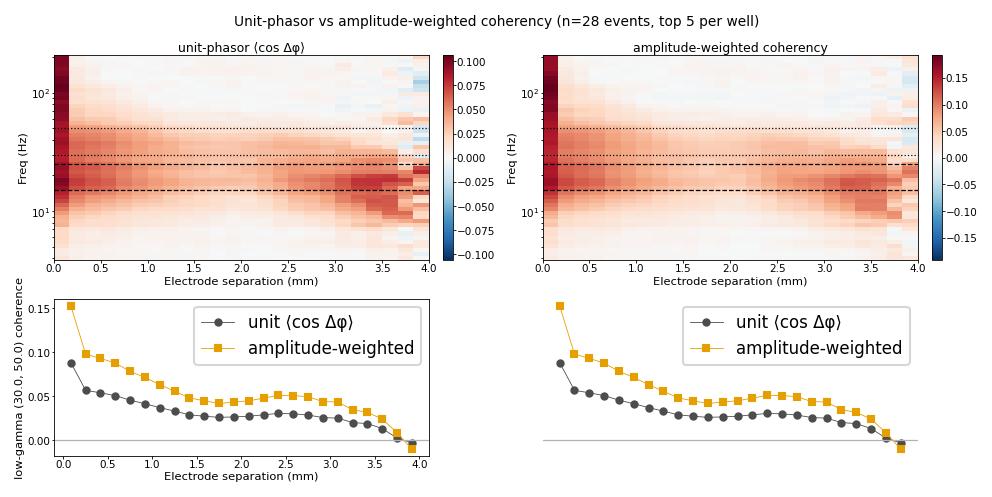

In [29]:
_unit = np.nanmean([band_distance_map(b, distance_bins(b["coords"], diag_edges), weighting="unit") for b in diag_banks], axis=0)
_cohy = np.nanmean([band_distance_map(b, distance_bins(b["coords"], diag_edges), weighting="coherency") for b in diag_banks], axis=0)
_ctr = distance_bins(diag_banks[0]["coords"], diag_edges)["centers"]

fig, axes = plt.subplots(2, 2, figsize=(6.5, 3.2), constrained_layout=True, gridspec_kw={"height_ratios":[1.3,1.0]})
for ax, M, ttl in [(axes[0,0], _unit, "unit-phasor ⟨cos Δφ⟩"), (axes[0,1], _cohy, "amplitude-weighted coherency")]:
    vmax = max(float(np.nanmax(np.abs(M))), 1e-9)
    mesh = ax.pcolormesh(_ctr, coh_band_centers, np.ma.masked_invalid(M), shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    for e in DIAG_LOWGAMMA_HZ: ax.axhline(e, color="k", lw=0.6, ls=":")
    for e in DIAG_BETA_HZ: ax.axhline(e, color="k", lw=0.6, ls="--")
    ax.set_yscale("log"); ax.set(xlabel="Electrode separation (mm)", ylabel="Freq (Hz)", title=ttl)
    fig.colorbar(mesh, ax=ax, pad=0.015)
for ax in axes[1]:
    ax.plot(_ctr, np.nanmean(_unit[lowgamma_band_mask], axis=0), "o-", color="0.3", ms=3, label="unit ⟨cos Δφ⟩")
    ax.plot(_ctr, np.nanmean(_cohy[lowgamma_band_mask], axis=0), "s-", color=FIGURE3_ACCENT_COLOR, ms=3, label="amplitude-weighted")
    ax.axhline(0, color="0.7", lw=0.6); ax.set(xlabel="Electrode separation (mm)", ylabel=f"low-gamma {DIAG_LOWGAMMA_HZ} coherence")
    ax.legend(fontsize=8)
axes[1,1].axis("off")
fig.suptitle(f"Unit-phasor vs amplitude-weighted coherency (n={len(diag_banks)} events, top {DIAG_N_PER_WELL} per well)")
plt.show()

## 1b · Coherence vs distance across frequency groups — does the wavelength shift?
Fine suboctave bands (kept for valid bandpass/Hilbert) are averaged into wider log-spaced frequency
groups. The ephaptic-axonal model predicts the interference wavelength scales as `λ = 1/[f(1/v_eph − 1/v_ax)]`
(∝ 1/f), so the ripple should move to **shorter** separations at higher frequency.

/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_71473/2695044615.py:38: RuntimeWarning: Mean of empty slice
  ev_cr = np.nanmean(_per_event[:, m, :], axis=1)                 # (n_events, n_bins)


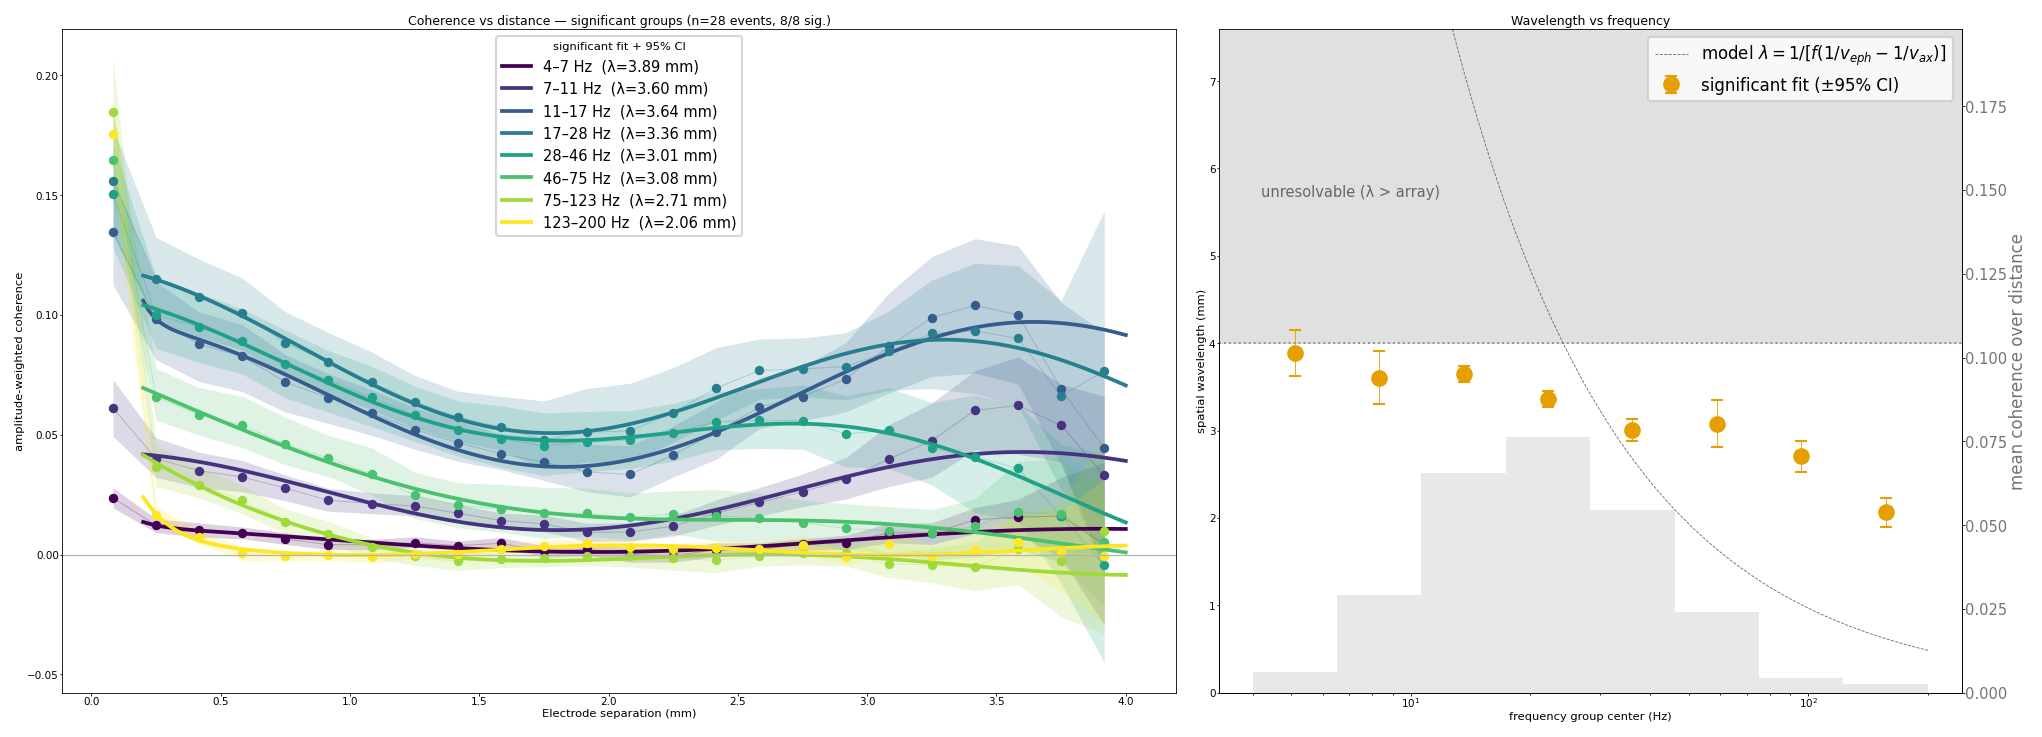

In [30]:
DIAG_N_FREQ_GROUPS = 8
DIAG_MODEL_VAX_MM_PER_MS = 0.62
DIAG_WL_CEILING_MM = DIAG_FIT_MAX_MM     # max resolvable wavelength ~ the fit range; larger => unresolvable
DIAG_SIG_DBIC = -4.0                      # exp+cos must beat exp by this (positive BIC evidence)
DIAG_WL_MAX_REL_CI = 0.40                 # fitted-wavelength std must be < this fraction of lambda (well-constrained)
DIAG_GROUP_BOOTSTRAP = 400

def _fit_group(centers, cr, weights, wl_hi):
    """exp vs exp+cos fit; returns params, dBIC, wavelength and its std (from the fit covariance)."""
    m = np.isfinite(cr) & (centers >= DIAG_FIT_MIN_MM) & (centers <= DIAG_FIT_MAX_MM)
    if m.sum() < 6:
        return None
    r, y, w = centers[m], cr[m], np.maximum(weights[m], 1e-9); sig = 1.0 / np.sqrt(w)
    try:
        pe, _ = curve_fit(_exp, r, y, p0=[max(y.max()-y.min(),1e-3),1.0,float(np.median(y))], sigma=sig, maxfev=40000, bounds=([0,.05,-1],[3,20,1]))
        pf, pcov = curve_fit(_expcos, r, y, p0=[*pe,.05,min(2.3,wl_hi)], sigma=sig, maxfev=80000,
                             bounds=([0,.05,-1,0,0.3],[3,20,1,1,wl_hi]))
    except Exception:
        return None
    rss_e = float(np.sum(w*(y-_exp(r,*pe))**2)); rss_f = float(np.sum(w*(y-_expcos(r,*pf))**2))
    wl_sd = float(np.sqrt(pcov[4, 4])) if np.all(np.isfinite(pcov)) else np.inf
    return {"p_exp": pe, "p_full": pf, "wavelength": float(pf[4]), "wl_sd": wl_sd,
            "dbic": float(r.size*np.log(rss_f/rss_e) + 2*np.log(r.size))}

_group_edges = np.geomspace(PHASE_COH_FREQ_LOW_HZ, PHASE_COH_FREQ_HIGH_HZ, DIAG_N_FREQ_GROUPS + 1)
_group_centers = np.sqrt(_group_edges[:-1] * _group_edges[1:])
_db0 = distance_bins(diag_banks[0]["coords"], diag_edges); _ctr, _counts = _db0["centers"], _db0["counts"]
_per_event = np.asarray([band_distance_map(b, distance_bins(b["coords"], diag_edges), weighting="coherency") for b in diag_banks])
_n_ev = _per_event.shape[0]; _rng = np.random.default_rng(0)

_groups = []
for gi in range(DIAG_N_FREQ_GROUPS):
    lo, hi = _group_edges[gi], _group_edges[gi + 1]
    upper = (coh_band_centers <= hi) if gi == DIAG_N_FREQ_GROUPS - 1 else (coh_band_centers < hi)
    m = (coh_band_centers >= lo) & upper
    if not m.any():
        continue
    ev_cr = np.nanmean(_per_event[:, m, :], axis=1)                 # (n_events, n_bins)
    cr = np.nanmean(ev_cr, axis=0)
    boot = np.array([np.nanmean(ev_cr[_rng.integers(0, _n_ev, _n_ev)], axis=0) for _ in range(DIAG_GROUP_BOOTSTRAP)])
    cilo, cihi = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    fit = _fit_group(_ctr, cr, _counts, wl_hi=DIAG_WL_CEILING_MM * 1.4)
    reliable = bool(fit and fit["dbic"] < DIAG_SIG_DBIC and fit["wavelength"] < DIAG_WL_CEILING_MM
                    and fit["wl_sd"] < DIAG_WL_MAX_REL_CI * fit["wavelength"])
    railed = bool(fit and fit["dbic"] < DIAG_SIG_DBIC and fit["wavelength"] >= DIAG_WL_CEILING_MM)
    _groups.append({"gi": gi, "lo": lo, "hi": hi, "center": _group_centers[gi], "cr": cr,
                    "cilo": cilo, "cihi": cihi, "fit": fit, "reliable": reliable, "railed": railed})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True, gridspec_kw={"width_ratios": [1.5, 1.0]})
_cmap = plt.cm.viridis
_n_sig = sum(g["reliable"] for g in _groups)
for g in _groups:                                                    # faint context for every group
    axL.plot(_ctr, g["cr"], "-", lw=0.5, color=_cmap(g["gi"] / max(DIAG_N_FREQ_GROUPS - 1, 1)), alpha=0.25)
for g in _groups:                                                    # significant groups: CI band + points + fitted curve
    if not g["reliable"]:
        continue
    col = _cmap(g["gi"] / max(DIAG_N_FREQ_GROUPS - 1, 1))
    axL.fill_between(_ctr, g["cilo"], g["cihi"], color=col, alpha=0.18, lw=0)
    axL.plot(_ctr, g["cr"], "o", color=col, ms=3.5)
    _rr = np.linspace(DIAG_FIT_MIN_MM, DIAG_FIT_MAX_MM, 200)
    axL.plot(_rr, _expcos(_rr, *g["fit"]["p_full"]), "-", color=col, lw=1.8,
             label=f"{g['lo']:.0f}–{g['hi']:.0f} Hz  (λ={g['fit']['wavelength']:.2f} mm)")
axL.axhline(0, color="0.7", lw=0.6)
axL.set(xlabel="Electrode separation (mm)", ylabel="amplitude-weighted coherence",
        title=f"Coherence vs distance — significant groups (n={len(diag_banks)} events, {_n_sig}/{len(_groups)} sig.)")
if _n_sig:
    axL.legend(fontsize=7, title="significant fit + 95% CI")

_sig = [g for g in _groups if g["reliable"]]
_rail = [g for g in _groups if g["railed"]]
if _sig:
    axR.errorbar([g["center"] for g in _sig], [g["fit"]["wavelength"] for g in _sig],
                 yerr=[1.96 * g["fit"]["wl_sd"] for g in _sig], fmt="o", color=FIGURE3_ACCENT_COLOR,
                 ms=7, capsize=3, label="significant fit (±95% CI)")
if _rail:
    axR.plot([g["center"] for g in _rail], [DIAG_WL_CEILING_MM] * len(_rail), "^", mfc="none",
             mec="0.4", ms=9, label="λ ≥ array (unresolvable)")
axR.axhspan(DIAG_WL_CEILING_MM, DIAG_WL_CEILING_MM * 1.9, color="0.88", zorder=0)
axR.axhline(DIAG_WL_CEILING_MM, color="0.55", lw=0.9, ls=":")
axR.text(_group_edges[0] * 1.05, DIAG_WL_CEILING_MM * 1.42, "unresolvable (λ > array)", fontsize=7, color="0.4")
try:
    _veph = float(speed_panel_hierarchical_summary["median_mm_per_s"]); _vax = DIAG_MODEL_VAX_MM_PER_MS * 1000.0
    _ff = np.geomspace(_group_edges[0], _group_edges[-1], 200)
    axR.plot(_ff, 1.0 / (_ff * (1.0 / _veph - 1.0 / _vax)), "--", color="0.4",
             label=r"model $\lambda=1/[f(1/v_{eph}-1/v_{ax})]$")
except Exception:
    pass
# marginal (semi-transparent): distance-averaged coherence level per frequency group -> shows where
# in frequency the coherence is concentrated (drawn behind the wavelength points on a twin axis).
_fitbins = (_ctr >= DIAG_FIT_MIN_MM) & (_ctr <= DIAG_FIT_MAX_MM)
_coh_level = np.full(DIAG_N_FREQ_GROUPS, np.nan)
for g in _groups:
    _coh_level[g["gi"]] = float(np.nanmean(g["cr"][_fitbins]))
axRb = axR.twinx()
axRb.set_zorder(axR.get_zorder() - 1); axR.patch.set_visible(False)
axRb.stairs(np.nan_to_num(_coh_level), _group_edges, fill=True, color="0.45", alpha=0.16, baseline=0.0)
axRb.set_ylim(0, np.nanmax(_coh_level) * 2.6 if np.any(np.isfinite(_coh_level)) else 1.0)
axRb.set_ylabel("mean coherence over distance", color="0.45", fontsize=8)
axRb.tick_params(axis="y", labelcolor="0.45", labelsize=7)

axR.set(xlabel="frequency group center (Hz)", ylabel="spatial wavelength (mm)", title="Wavelength vs frequency",
        xscale="log", ylim=(0, DIAG_WL_CEILING_MM * 1.9))
axR.legend(fontsize=8, loc="upper right")
plt.show()

## 1c · Per-band coordinate-shuffle null (calibrated significance)
Permutes electrode positions per event/band, re-bins the unchanged pairwise coherences -> a flat null
C(r) at each band's chance level. The ripple is significant only if its exp+cos ΔBIC beats the null ΔBIC
distribution (p < α); coherence is real only where it clears the null band. Replaces the ad-hoc gates.

/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


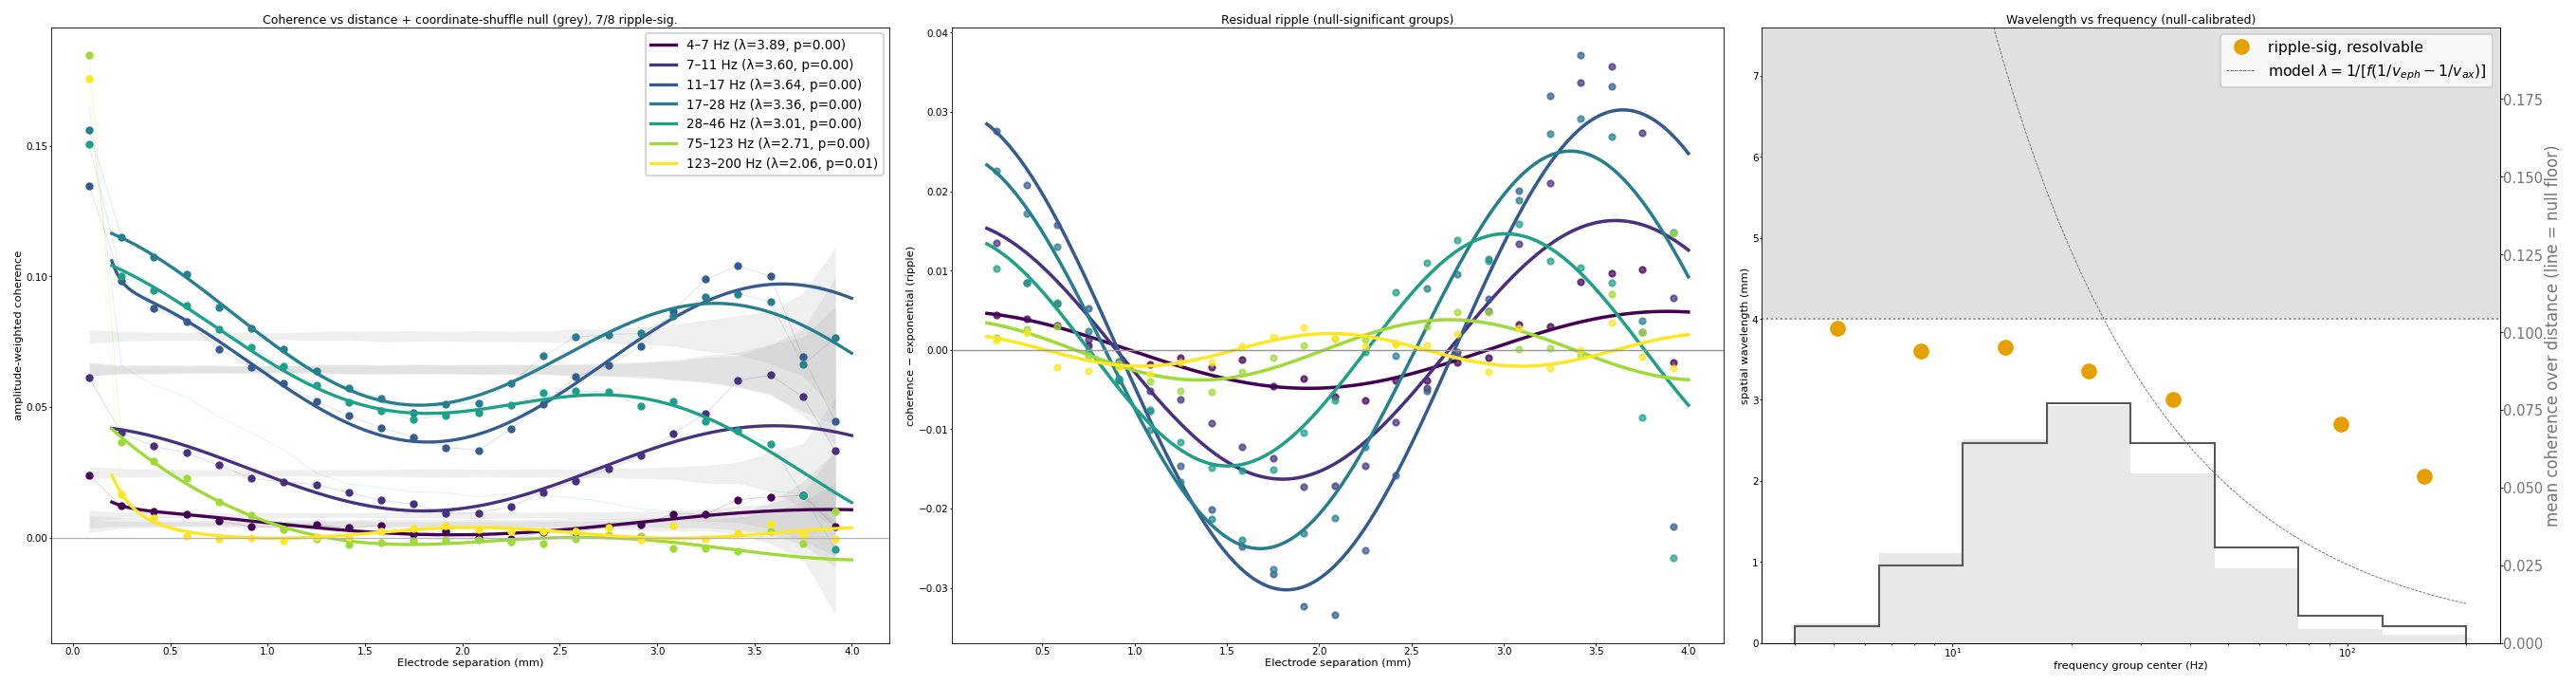

null-calibrated: 7/8 groups ripple-significant (p<0.05); 200 null reps


In [31]:
# --- Per-band coordinate-shuffle null: is the distance structure / ripple beyond chance? ---
# For each event and band, keep the analytic signals but permute electrode POSITIONS, recompute pairwise
# distances, and re-bin the (unchanged) pairwise coherences. This destroys the coherence-vs-distance link
# while preserving the finite-sample bias, amplitude weighting, temporal phase structure and global
# synchrony -> a FLAT null C(r) at the band's chance level. Aggregated over events and pooled into the
# same frequency groups. A group's ripple is significant only if its exp+cos dBIC beats the null dBIC
# distribution (p < DIAG_NULL_ALPHA); its coherence is real only if it clears the null band.
DIAG_NULL_REPS = 200
DIAG_NULL_ALPHA = 0.05

_dctr = 0.5 * (diag_edges[:-1] + diag_edges[1:])
_nb = len(diag_edges) - 1
_nbands = len(coh_bands)
_fitmask = (_dctr >= DIAG_FIT_MIN_MM) & (_dctr <= DIAG_FIT_MAX_MM)
_pair_counts = distance_bins(diag_banks[0]["coords"], diag_edges)["counts"]
_nrng = np.random.default_rng(0)

def _binmap_nd(num, den, bins, minp=DIAG_MIN_PAIRS):
    cnt = np.bincount(bins, minlength=_nb)
    n = np.bincount(bins, weights=num, minlength=_nb); dd = np.bincount(bins, weights=den, minlength=_nb)
    c = np.full(_nb, np.nan); np.divide(n, dd, out=c, where=dd > 0); c[cnt < minp] = np.nan
    return c

from joblib import Parallel, delayed

def _null_one_event(bank, edges, R, min_pairs, seed):
    """One event: per-band pairwise coherence, observed + R coordinate-shuffle null C(r).
    All 28 bands are binned in ONE bincount per rep (flat band*bin index); pair counts (preserved
    by the shuffle) are reused for masking -> no per-rep/per-band bincount loop."""
    coords = np.asarray(bank["coords"], float); cm = bank["core_mask"]; N = coords.shape[0]; nbins = len(edges) - 1
    iu = np.triu_indices(N, 1)
    d = np.linalg.norm(coords[iu[0]] - coords[iu[1]], axis=1)
    inr = d <= edges[-1]; iu0, iu1, d = iu[0][inr], iu[1][inr], d[inr]
    obs_bins = np.clip(np.digitize(d, edges) - 1, 0, nbins - 1)
    mask = np.bincount(obs_bins, minlength=nbins) < min_pairs
    nbands = bank["u"].shape[0]
    num = np.empty((nbands, iu0.size), np.float32); den = np.empty((nbands, iu0.size), np.float32)
    for bi in range(nbands):
        zc = (bank["u"][bi] * bank["amp"][bi])[cm]
        cross = zc.conj().T @ zc; p = np.sum(np.abs(zc) ** 2, axis=0)
        num[bi] = np.real(cross)[iu0, iu1]; den[bi] = np.sqrt(p[iu0] * p[iu1])
    num_r, den_r = num.ravel(), den.ravel(); band_off = (np.arange(nbands) * nbins)[:, None]
    def _binned(bins):
        flat = (band_off + bins[None, :]).ravel()
        nn = np.bincount(flat, num_r, minlength=nbands * nbins).reshape(nbands, nbins)
        dd = np.bincount(flat, den_r, minlength=nbands * nbins).reshape(nbands, nbins)
        c = np.full((nbands, nbins), np.nan); np.divide(nn, dd, out=c, where=dd > 0); c[:, mask] = np.nan
        return c
    obs = _binned(obs_bins); rng = np.random.default_rng(seed); null = np.empty((nbands, R, nbins), np.float32)
    for r in range(R):
        pi = rng.permutation(N)
        null[:, r, :] = _binned(np.clip(np.digitize(np.linalg.norm(coords[pi[iu0]] - coords[pi[iu1]], axis=1), edges) - 1, 0, nbins - 1))
    return obs, null

_null_args = [(b, diag_edges, DIAG_NULL_REPS, DIAG_MIN_PAIRS, 100 + i) for i, b in enumerate(diag_banks)]
try:
    _ev = Parallel(n_jobs=-1)(delayed(_null_one_event)(*a) for a in _null_args)
except Exception as _exc:
    print(f"parallel null unavailable ({_exc}); serial"); _ev = [_null_one_event(*a) for a in _null_args]
_obs_agg = np.nanmean(np.stack([o for o, _ in _ev]), axis=0)
_null_agg = np.nanmean(np.stack([n for _, n in _ev]), axis=0)

def _dbic_wl(cr):
    m = np.isfinite(cr) & _fitmask
    if m.sum() < 6:
        return np.nan, np.nan, None
    r, y, w = _dctr[m], cr[m], np.maximum(_pair_counts[m], 1e-9); sig = 1.0 / np.sqrt(w)
    try:
        pe, _ = curve_fit(_exp, r, y, p0=[max(y.max()-y.min(),1e-3),1.0,float(np.median(y))], sigma=sig, maxfev=40000, bounds=([0,.05,-1],[3,20,1]))
        pf, _ = curve_fit(_expcos, r, y, p0=[*pe,.05,min(2.3, DIAG_WL_CEILING_MM*1.4)], sigma=sig, maxfev=80000,
                          bounds=([0,.05,-1,0,0.3],[3,20,1,1,DIAG_WL_CEILING_MM*1.4]))
    except Exception:
        return np.nan, np.nan, None
    re = float(np.sum(w*(y-_exp(r,*pe))**2)); rf = float(np.sum(w*(y-_expcos(r,*pf))**2))
    return float(r.size*np.log(rf/re) + 2*np.log(r.size)), float(pf[4]), pf

_ge = np.geomspace(PHASE_COH_FREQ_LOW_HZ, PHASE_COH_FREQ_HIGH_HZ, DIAG_N_FREQ_GROUPS + 1)
_gc = np.sqrt(_ge[:-1] * _ge[1:])

def _group_dbics(obs_cr, null_cr):
    """obs + per-rep null dBICs for one frequency group. The DIAG_NULL_REPS exp/exp+cos null
    curve_fits (maxfev up to 80000 on near-flat noisy curves) are the dominant serial cost."""
    obs_dbic, obs_wl, obs_pf = _dbic_wl(obs_cr)
    null_dbics = np.array([_dbic_wl(null_cr[r])[0] for r in range(null_cr.shape[0])])
    return obs_dbic, obs_wl, obs_pf, null_dbics

_gmeta = []                                                              # non-empty groups + pooled curves
for gi in range(DIAG_N_FREQ_GROUPS):
    lo, hi = _ge[gi], _ge[gi + 1]
    upper = (coh_band_centers <= hi) if gi == DIAG_N_FREQ_GROUPS - 1 else (coh_band_centers < hi)
    bmask = (coh_band_centers >= lo) & upper
    if not bmask.any():
        continue
    _gmeta.append((gi, lo, hi, np.nanmean(_obs_agg[bmask], axis=0), np.nanmean(_null_agg[bmask], axis=0)))

# the (n_groups x DIAG_NULL_REPS) null fits dominate runtime -> parallelize across groups (bit-identical)
try:
    _gstats = Parallel(n_jobs=-1)(delayed(_group_dbics)(m[3], m[4]) for m in _gmeta)
except Exception as _exc:
    print(f"parallel dBIC unavailable ({_exc}); serial"); _gstats = [_group_dbics(m[3], m[4]) for m in _gmeta]

_ng = []
for (gi, lo, hi, obs_cr, null_cr), (obs_dbic, obs_wl, obs_pf, null_dbics) in zip(_gmeta, _gstats):
    null_lo, null_hi = np.nanpercentile(null_cr, [2.5, 97.5], axis=0)
    null_level = float(np.nanmean(null_cr))
    p_ripple = float(np.nanmean(null_dbics <= obs_dbic)) if np.isfinite(obs_dbic) else 1.0
    # null-calibrated: the ripple is significant only if its exp+cos dBIC beats the null dBIC distribution.
    # (This alone rejects near-zero-noise bands and pure-decay bands; the coordinate-shuffle null preserves
    #  the MEAN coherence, so a mean-level gate would be meaningless -- the ripple is in the shape.)
    ripple_sig = bool(np.isfinite(obs_dbic) and p_ripple < DIAG_NULL_ALPHA)
    _ng.append({"gi": gi, "lo": lo, "hi": hi, "center": _gc[gi], "obs": obs_cr, "null_lo": null_lo, "null_hi": null_hi,
                "null_level": null_level, "obs_wl": obs_wl, "obs_pf": obs_pf, "p_ripple": p_ripple,
                "ripple_sig": ripple_sig,
                "resolvable": bool(ripple_sig and np.isfinite(obs_wl) and obs_wl < DIAG_WL_CEILING_MM),
                "unresolvable": bool(ripple_sig and np.isfinite(obs_wl) and obs_wl >= DIAG_WL_CEILING_MM)})

_sig = [g for g in _ng if g["ripple_sig"]]
_res = [g for g in _ng if g["resolvable"]]
_unr = [g for g in _ng if g["unresolvable"]]
_cmap = plt.cm.viridis
def _col(g): return _cmap(g["gi"] / max(DIAG_N_FREQ_GROUPS - 1, 1))
_rr = np.linspace(DIAG_FIT_MIN_MM, DIAG_FIT_MAX_MM, 250)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(18, 4.7), constrained_layout=True, gridspec_kw={"width_ratios": [1.25, 1.15, 1.1]})
for g in _ng:
    axA.plot(_dctr, g["obs"], "-", lw=0.4, color=_col(g), alpha=0.2)
for g in _sig:
    col = _col(g)
    axA.fill_between(_dctr, g["null_lo"], g["null_hi"], color="0.6", alpha=0.15, lw=0)   # null band
    axA.plot(_dctr, g["obs"], "o", color=col, ms=3)
    if g["obs_pf"] is not None:
        axA.plot(_rr, _expcos(_rr, *g["obs_pf"]), "-", color=col, lw=1.6,
                 label=f"{g['lo']:.0f}–{g['hi']:.0f} Hz (λ={g['obs_wl']:.2f}{'*' if g['unresolvable'] else ''}, p={g['p_ripple']:.2f})")
axA.axhline(0, color="0.7", lw=0.6)
axA.set(xlabel="Electrode separation (mm)", ylabel="amplitude-weighted coherence",
        title=f"Coherence vs distance + coordinate-shuffle null (grey), {len(_sig)}/{len(_ng)} ripple-sig.")
if _sig:
    axA.legend(fontsize=6.5)
for g in _sig:
    if g["obs_pf"] is None:
        continue
    a, lam, b, c, wl = g["obs_pf"]
    resid = g["obs"] - (a * np.exp(-_dctr / lam) + b)
    axB.plot(_dctr[_fitmask], resid[_fitmask], "o", color=_col(g), ms=3, alpha=0.7)
    axB.plot(_rr, c * np.cos(2 * np.pi * _rr / wl), "-", color=_col(g), lw=1.7)
axB.axhline(0, color="0.6", lw=0.7)
axB.set(xlabel="Electrode separation (mm)", ylabel="coherence − exponential (ripple)", title="Residual ripple (null-significant groups)")

if _res:
    axC.plot([g["center"] for g in _res], [g["obs_wl"] for g in _res], "o", color=FIGURE3_ACCENT_COLOR, ms=7, label="ripple-sig, resolvable")
if _unr:
    axC.plot([g["center"] for g in _unr], [DIAG_WL_CEILING_MM] * len(_unr), "^", color=FIGURE3_ACCENT_COLOR, mfc="none", mew=1.6, ms=10, label="ripple-sig, λ ≥ array")
axC.axhspan(DIAG_WL_CEILING_MM, DIAG_WL_CEILING_MM * 1.9, color="0.88", zorder=0)
axC.axhline(DIAG_WL_CEILING_MM, color="0.55", lw=0.9, ls=":")
try:
    _veph = float(speed_panel_hierarchical_summary["median_mm_per_s"]); _vax = DIAG_MODEL_VAX_MM_PER_MS * 1000.0
    _ff = np.geomspace(_ge[0], _ge[-1], 200)
    axC.plot(_ff, 1.0 / (_ff * (1.0 / _veph - 1.0 / _vax)), "--", color="0.4", label=r"model $\lambda=1/[f(1/v_{eph}-1/v_{ax})]$")
except Exception:
    pass
_lvl = np.full(DIAG_N_FREQ_GROUPS, np.nan); _nulllvl = np.full(DIAG_N_FREQ_GROUPS, np.nan)
for g in _ng:
    _lvl[g["gi"]] = float(np.nanmean(g["obs"][_fitmask])); _nulllvl[g["gi"]] = g["null_level"]
axCb = axC.twinx(); axCb.set_zorder(axC.get_zorder() - 1); axC.patch.set_visible(False)
axCb.stairs(np.nan_to_num(_lvl), _ge, fill=True, color="0.45", alpha=0.16, baseline=0.0)
axCb.stairs(np.nan_to_num(_nulllvl), _ge, color="0.35", lw=1.0, baseline=0.0)   # null floor per group
axCb.set_ylim(0, np.nanmax(_lvl) * 2.6 if np.any(np.isfinite(_lvl)) else 1.0)
axCb.set_ylabel("mean coherence over distance (line = null floor)", color="0.45", fontsize=8)
axCb.tick_params(axis="y", labelcolor="0.45", labelsize=7)
axC.set(xlabel="frequency group center (Hz)", ylabel="spatial wavelength (mm)", title="Wavelength vs frequency (null-calibrated)",
        xscale="log", ylim=(0, DIAG_WL_CEILING_MM * 1.9))
axC.legend(fontsize=7.5, loc="upper right")
plt.show()
print(f"null-calibrated: {len(_sig)}/{len(_ng)} groups ripple-significant (p<{DIAG_NULL_ALPHA}); {DIAG_NULL_REPS} null reps")

## 2 · Coherence-over-distance through the burst — `C(r, t)`
Low-gamma coherency in a sliding ±20 ms window across the display window, anchor-aligned. Tests whether coherence-over-distance peaks at the burst peak.

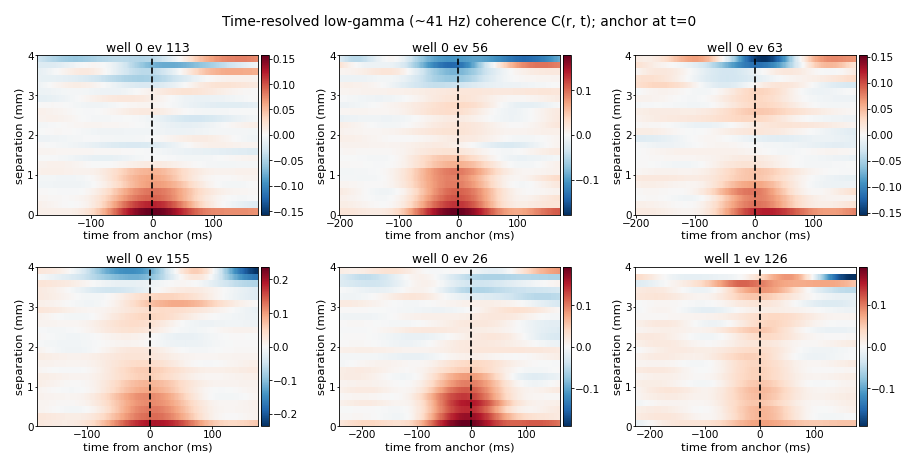

In [32]:
def time_resolved_cr(bank, edges, band_idx, *, win_ms=DIAG_TIME_WIN_MS):
    db = distance_bins(bank["coords"], edges)
    z = bank["u"][band_idx] * bank["amp"][band_idx]        # (T, N) analytic signal
    win = max(1, int(round(win_ms / 1000.0 * FS_DS)))
    tt = np.flatnonzero(bank["disp_mask"])
    Crt = np.full((len(db["counts"]), tt.size), np.nan)
    for k, ti in enumerate(tt):
        zw = z[max(0, ti - win):min(z.shape[0], ti + win + 1)]
        cross = zw.conj().T @ zw; p = np.sum(np.abs(zw) ** 2, axis=0)
        num = np.bincount(db["bin_idx"], weights=np.real(cross)[db["iu0"], db["iu1"]], minlength=len(db["counts"]))
        den = np.bincount(db["bin_idx"], weights=np.sqrt(p[db["iu0"]] * p[db["iu1"]]), minlength=len(db["counts"]))
        col = np.full(len(db["counts"]), np.nan); np.divide(num, den, out=col, where=den > 0)
        col[db["counts"] < db["min_pairs"]] = np.nan; Crt[:, k] = col
    return Crt, bank["t"][tt] - bank["anchor_time_s"], db["centers"]

_gamma_band = int(np.argmin(np.abs(coh_band_centers - 40.0)))
fig, axes = plt.subplots(2, 3, figsize=(6, 3), constrained_layout=True)
for ax, bank in zip(axes.ravel(), diag_banks):
    Crt, t_rel, ctr = time_resolved_cr(bank, diag_edges, _gamma_band)
    vmax = max(float(np.nanmax(np.abs(Crt))), 1e-9)
    mesh = ax.pcolormesh(t_rel * 1000, ctr, np.ma.masked_invalid(Crt), shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set(xlabel="time from anchor (ms)", ylabel="separation (mm)", title=f"well {bank['well']} ev {bank['event_idx']}")
    fig.colorbar(mesh, ax=ax, pad=0.015)
fig.suptitle(f"Time-resolved low-gamma (~{coh_band_centers[_gamma_band]:.0f} Hz) coherence C(r, t); anchor at t=0")
plt.show()

## 3 · Distance-binning sweep
How the low-gamma C(r) and fitted wavelength depend on bin count / max separation.

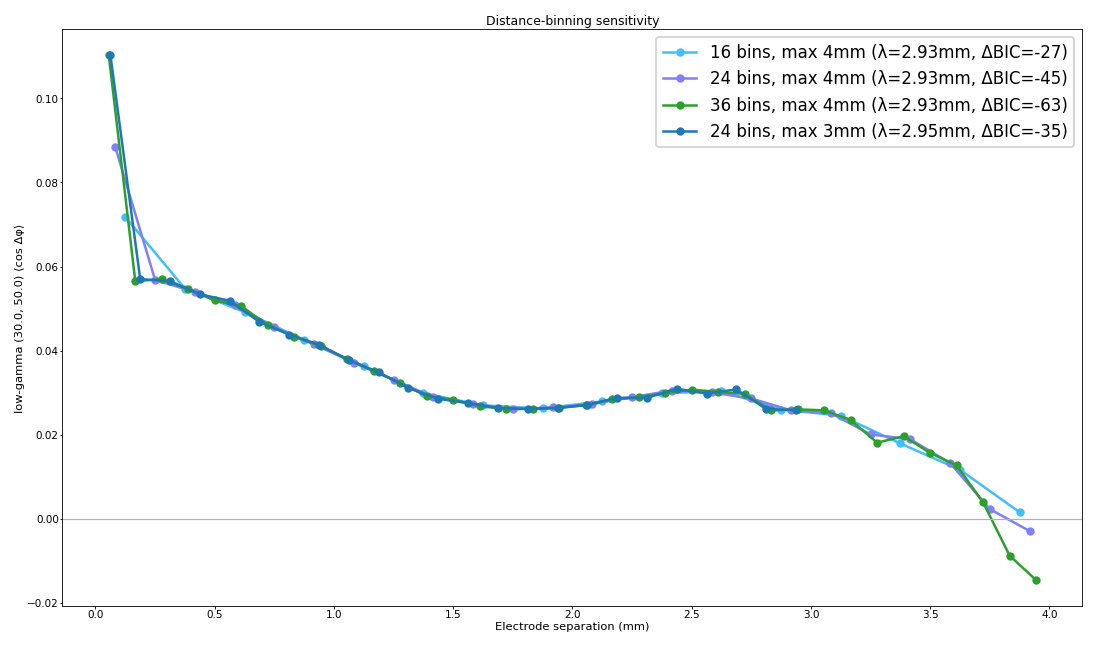

In [33]:
_binning_settings = [(16, 4.0), (24, 4.0), (36, 4.0), (24, 3.0)]
fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
for n_bins, dmax in _binning_settings:
    edges = np.linspace(0.0, dmax, n_bins + 1)
    maps = []; counts = None
    for b in diag_banks:
        db = distance_bins(b["coords"], edges); counts = db["counts"]
        maps.append(band_distance_map(b, db, weighting="unit"))
    agg = np.nanmean(maps, axis=0); cr = np.nanmean(agg[lowgamma_band_mask], axis=0)
    ctr = 0.5 * (edges[:-1] + edges[1:])
    fit = fit_lowgamma_wavelength(ctr, cr, counts)
    lab = f"{n_bins} bins, max {dmax:g}mm" + (f" (λ={fit['wavelength']:.2f}mm, ΔBIC={fit['dbic']:.0f})" if fit else "")
    ax.plot(ctr, cr, "o-", ms=3, lw=1.2, label=lab)
ax.axhline(0, color="0.7", lw=0.6)
ax.set(xlabel="Electrode separation (mm)", ylabel=f"low-gamma {DIAG_LOWGAMMA_HZ} ⟨cos Δφ⟩", title="Distance-binning sensitivity")
ax.legend(fontsize=8)
plt.show()

## 4 · Averaging-window sweep
Full burst core vs peri-anchor windows of increasing width.

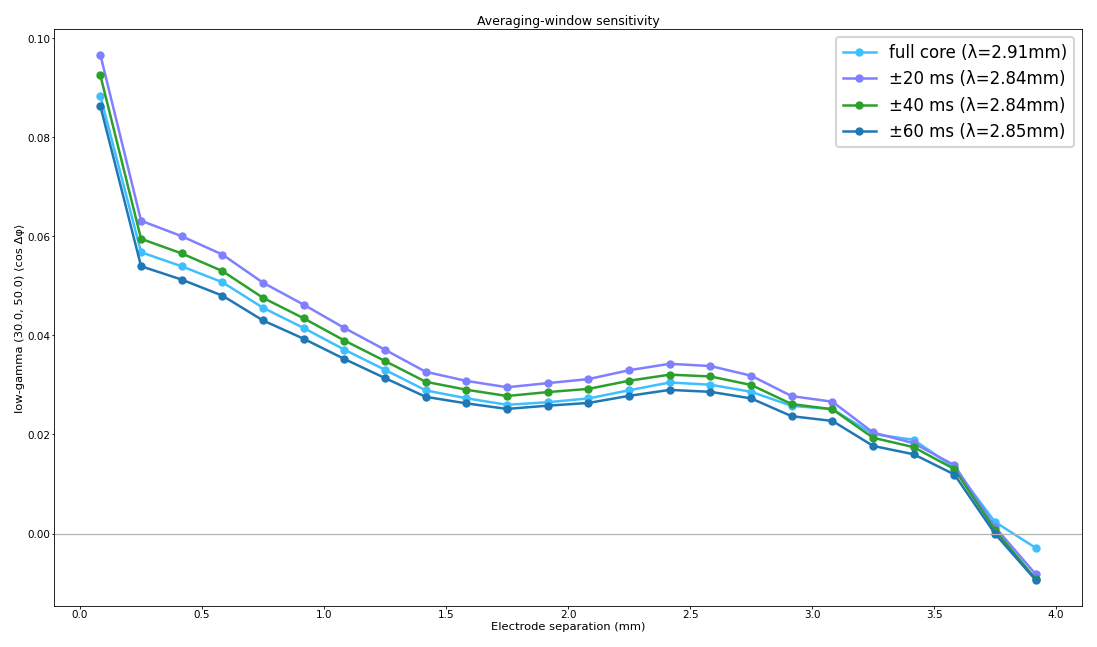

In [34]:
def _peri_anchor_mask(bank, half_ms):
    a = bank["anchor_time_s"]; return (bank["t"] >= a - half_ms/1000) & (bank["t"] <= a + half_ms/1000)
_window_settings = [("full core", None), ("±20 ms", 20.0), ("±40 ms", 40.0), ("±60 ms", 60.0)]
_edges = diag_edges; _ctr = 0.5 * (_edges[:-1] + _edges[1:]); _counts = distance_bins(diag_banks[0]["coords"], _edges)["counts"]
fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
for label, half in _window_settings:
    maps = []
    for b in diag_banks:
        wm = None if half is None else _peri_anchor_mask(b, half)
        maps.append(band_distance_map(b, distance_bins(b["coords"], _edges), weighting="unit", window_mask=wm))
    cr = np.nanmean(np.nanmean(maps, axis=0)[lowgamma_band_mask], axis=0)
    fit = fit_lowgamma_wavelength(_ctr, cr, _counts)
    lab = label + (f" (λ={fit['wavelength']:.2f}mm)" if fit else "")
    ax.plot(_ctr, cr, "o-", ms=3, lw=1.2, label=lab)
ax.axhline(0, color="0.7", lw=0.6)
ax.set(xlabel="Electrode separation (mm)", ylabel=f"low-gamma {DIAG_LOWGAMMA_HZ} ⟨cos Δφ⟩", title="Averaging-window sensitivity")
ax.legend(fontsize=8)
plt.show()

## Channel-count check: effective channels & PHASE_COH_MAX_CHANNELS
Do we need all channels, or do most contribute negligibly? Ranks channels by low-gamma power and sweeps a top-N cap (amplitude-ranked) to see the effect on the coherence level, the order parameter + its finite-size floor, and the ripple wavelength.

low-gamma bands: [31.9 34.5 37.4 40.5 43.9 47.5] Hz


/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_71473/2725507148.py:24: RuntimeWarning: Mean of empty slice
  return np.nanmean(band_distance_map(bank, db, weighting="coherency")[_lg], axis=0), db["centers"]
/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_71473/2725507148.py:57: RuntimeWarning: Mean of empty slice
  _lvl_by_N[int(N_)].append(float(np.nanmean(cr[(_ctr >= DIAG_FIT_MIN_MM) & (_ctr <= DIAG_FIT_MAX_MM)])))
/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_71473/2725507148.py:62: RuntimeWarning: Mean of empty slice
  _lvl = np.array([np.nanmean(_lvl_by_N[int(N)]) for N in _Ngrid])
/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_71473/2725507148.py:65: RuntimeWarning: Mean of empty slice
  _lam = np.array([_fit_lambda(_ctr, np.nanmean(_cr_by_N[int(N)], axis=0)) for N in _Ngrid])


channels/event: median 1020 | effective N: power 544, amplitude-weight 891 | channels >5% peak power: 626


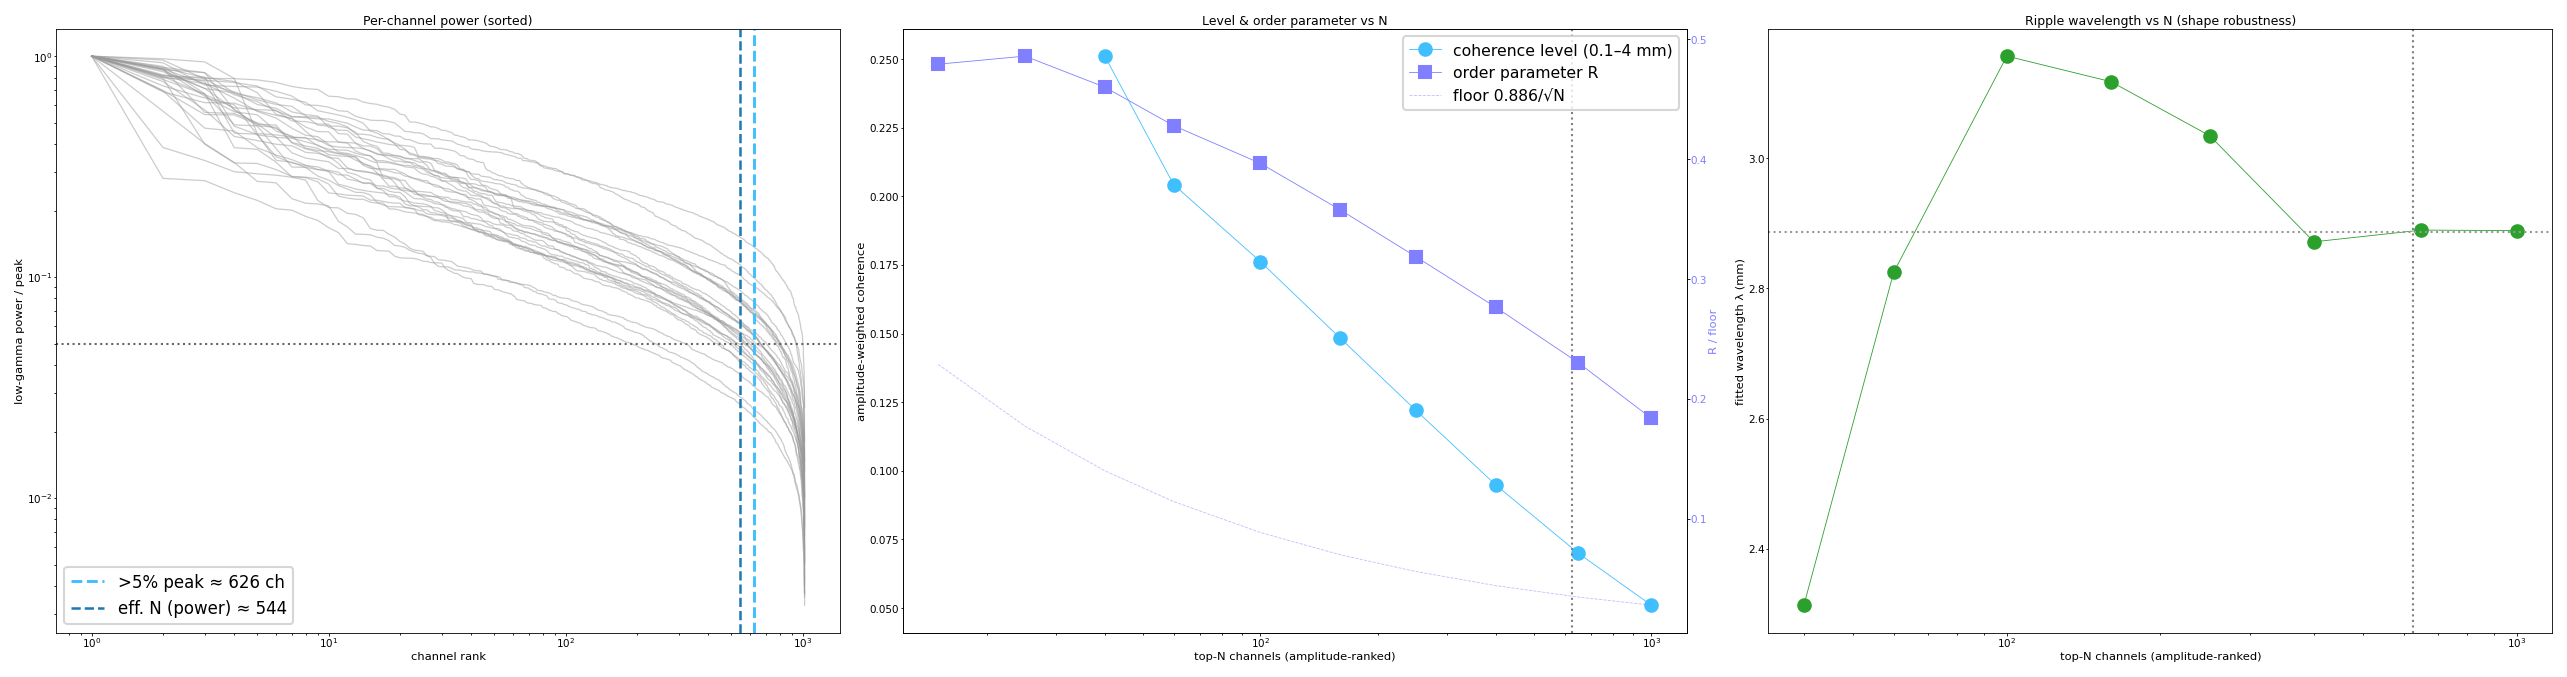


Only ~626 of 1020 channels clear 5% of peak power (effective N ≈ 544); the rest are low-amplitude.
Coherence LEVEL: top-626 = 0.070 vs all = 0.051  (extra channels DILUTE it).
Order parameter: top-626 R = 0.230 (floor 0.035, 6.5x) vs all R = 0.184 (floor 0.028, 6.6x).
Ripple wavelength: top-626 λ = 2.89 mm vs all λ = 2.89 mm  (shape robust to N).
=> PHASE_COH_USE_ALL_CHANNELS is not needed; ~626 amplitude-ranked channels suffice. Set PHASE_COH_MAX_CHANNELS≈626, but change the selection from even-index subsampling to amplitude-ranked.


In [35]:
# --- Channel-count check: how many channels actually carry LFP signal? ---
# The aggregate analysis uses ALL channels (PHASE_COH_USE_ALL_CHANNELS=True). On an HD-MEA most channels
# are low-amplitude / noisy-phase. This cell ranks channels by low-gamma LFP power on the cached
# diag_banks and asks (a) how many effectively contribute (participation ratio), (b) how the amplitude-
# weighted coherence LEVEL and the unit-phasor order parameter R (+ its finite-size floor 0.886/sqrt(N))
# change as we cap to the top-N channels, and (c) whether the ripple SHAPE/wavelength is robust to N.
# Note: low-amplitude channels are only mildly down-weighted by the sqrt(power) coherency weighting, so
# keeping all of them DILUTES the coherence and pins the order-parameter floor low; the ripple shape,
# set by the high-power channels, should be invariant. (The current PHASE_COH_MAX_CHANNELS just even-
# subsamples by index -> to act on this, selection must be amplitude-ranked instead.)
_lg = np.flatnonzero((coh_band_centers >= DIAG_LOWGAMMA_HZ[0]) & (coh_band_centers <= DIAG_LOWGAMMA_HZ[1]))
print(f"low-gamma bands: {coh_band_centers[_lg].round(1)} Hz")

def _chan_power(bank):
    z = bank["u"][_lg] * bank["amp"][_lg]
    return np.sum(np.abs(z[:, bank["core_mask"], :]) ** 2, axis=(0, 1))    # (N,)

def _subset(bank, idx):
    return {"coords": np.asarray(bank["coords"], float)[idx], "core_mask": bank["core_mask"],
            "u": bank["u"][:, :, idx], "amp": bank["amp"][:, :, idx]}

def _lg_cr(bank):
    db = distance_bins(bank["coords"], diag_edges)
    return np.nanmean(band_distance_map(bank, db, weighting="coherency")[_lg], axis=0), db["centers"]

def _R(bank, idx):
    u = bank["u"][_lg][:, bank["core_mask"], :][:, :, idx]
    return float(np.nanmean(np.abs(np.nanmean(u, axis=2))))

def _fit_lambda(ctr, cr):
    m = np.isfinite(cr) & (ctr >= DIAG_FIT_MIN_MM) & (ctr <= DIAG_FIT_MAX_MM)
    if m.sum() < 8:
        return np.nan
    r, y = ctr[m], cr[m]
    try:
        pe, _ = curve_fit(_exp, r, y, p0=[max(y.max()-y.min(),1e-3),1.0,float(np.median(y))], maxfev=20000, bounds=([0,.05,-1],[3,20,1]))
        pf, _ = curve_fit(_expcos, r, y, p0=[*pe,.02,2.3], maxfev=40000, bounds=([0,.05,-1,0,0.3],[3,20,1,1,5.6]))
        return float(pf[4])
    except Exception:
        return np.nan

_Ngrid = np.array([15, 25, 40, 60, 100, 160, 250, 400, 650, 1000])
_neff_pow, _neff_amp, _ntot, _nsig5, _pow_sorted = [], [], [], [], []
_lvl_by_N = {int(N): [] for N in _Ngrid}; _R_by_N = {int(N): [] for N in _Ngrid}; _cr_by_N = {int(N): [] for N in _Ngrid}
_ctr = None
for bank in diag_banks:
    P = _chan_power(bank); N = P.size; _ntot.append(N)
    _neff_pow.append((P.sum() ** 2) / np.sum(P ** 2))
    sp = np.sqrt(P); _neff_amp.append((sp.sum() ** 2) / np.sum(P))
    _nsig5.append(int(np.sum(P >= 0.05 * P.max())))                      # channels above 5% of peak power
    _pow_sorted.append(np.sort(P)[::-1] / P.max())
    order = np.argsort(P)[::-1]
    for N_ in _Ngrid:
        idx = order[:min(int(N_), N)]; rb = _subset(bank, idx)
        cr, _ctr = _lg_cr(rb)
        _cr_by_N[int(N_)].append(cr)
        _lvl_by_N[int(N_)].append(float(np.nanmean(cr[(_ctr >= DIAG_FIT_MIN_MM) & (_ctr <= DIAG_FIT_MAX_MM)])))
        _R_by_N[int(N_)].append(_R(bank, idx))

Ntot = int(np.median(_ntot)); Nsig = int(np.median(_nsig5))
neff_p = np.median(_neff_pow); neff_a = np.median(_neff_amp)
_lvl = np.array([np.nanmean(_lvl_by_N[int(N)]) for N in _Ngrid])
_R_ = np.array([np.nanmean(_R_by_N[int(N)]) for N in _Ngrid])
_floor = 0.8862 / np.sqrt(np.minimum(_Ngrid, Ntot).astype(float))
_lam = np.array([_fit_lambda(_ctr, np.nanmean(_cr_by_N[int(N)], axis=0)) for N in _Ngrid])
print(f"channels/event: median {Ntot} | effective N: power {neff_p:.0f}, amplitude-weight {neff_a:.0f} "
      f"| channels >5% peak power: {Nsig}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.4), constrained_layout=True)
for ps in _pow_sorted:
    ax1.plot(np.arange(1, ps.size + 1), ps, color="0.6", lw=0.6, alpha=0.5)
ax1.axhline(0.05, color="0.4", ls=":", lw=1)
ax1.axvline(Nsig, color="C0", ls="--", lw=1.4, label=f">5% peak ≈ {Nsig} ch")
ax1.axvline(neff_p, color="C3", ls="--", lw=1.2, label=f"eff. N (power) ≈ {neff_p:.0f}")
ax1.set(xscale="log", yscale="log", xlabel="channel rank", ylabel="low-gamma power / peak",
        title="Per-channel power (sorted)"); ax1.legend(fontsize=8)

ax2.plot(_Ngrid, _lvl, "o-", color="C0", label="coherence level (0.1–4 mm)")
ax2.axvline(Nsig, color="0.5", ls=":", lw=1)
ax2.set(xscale="log", xlabel="top-N channels (amplitude-ranked)", ylabel="amplitude-weighted coherence",
        title="Level & order parameter vs N")
ax2b = ax2.twinx()
ax2b.plot(_Ngrid, _R_, "s-", color="C1", label="order parameter R")
ax2b.plot(_Ngrid, _floor, "--", color="C1", alpha=0.5, label="floor 0.886/√N")
ax2b.set_ylabel("R / floor", color="C1"); ax2b.tick_params(axis="y", labelcolor="C1")
_h1, _la1 = ax2.get_legend_handles_labels(); _h2, _la2 = ax2b.get_legend_handles_labels()
ax2.legend(_h1 + _h2, _la1 + _la2, fontsize=7.5, loc="upper right")

ax3.plot(_Ngrid, _lam, "o-", color="C2")
ax3.axhline(np.nanmean(_lam), color="0.6", ls=":", lw=1)
ax3.axvline(Nsig, color="0.5", ls=":", lw=1)
ax3.set(xscale="log", xlabel="top-N channels (amplitude-ranked)", ylabel="fitted wavelength λ (mm)",
        title="Ripple wavelength vs N (shape robustness)")
plt.show()

_iN = int(np.argmin(np.abs(_Ngrid - Nsig)))
print(f"\nOnly ~{Nsig} of {Ntot} channels clear 5% of peak power (effective N ≈ {neff_p:.0f}); the rest are low-amplitude.")
print(f"Coherence LEVEL: top-{Nsig} = {_lvl[_iN]:.3f} vs all = {_lvl[-1]:.3f}  (extra channels DILUTE it).")
print(f"Order parameter: top-{Nsig} R = {_R_[_iN]:.3f} (floor {0.8862/np.sqrt(Nsig):.3f}, {_R_[_iN]/(0.8862/np.sqrt(Nsig)):.1f}x) "
      f"vs all R = {_R_[-1]:.3f} (floor {_floor[-1]:.3f}, {_R_[-1]/_floor[-1]:.1f}x).")
print(f"Ripple wavelength: top-{Nsig} λ = {_lam[_iN]:.2f} mm vs all λ = {_lam[-1]:.2f} mm  (shape robust to N).")
print(f"=> PHASE_COH_USE_ALL_CHANNELS is not needed; ~{Nsig} amplitude-ranked channels suffice. Set "
      f"PHASE_COH_MAX_CHANNELS≈{Nsig}, but change the selection from even-index subsampling to amplitude-ranked.")


## Phase-rotation null: coherence level vs chance
The coordinate-shuffle null tests distance *structure* but preserves the coherence *level*. To ask whether the coherence level is above chance, rotate each channel's phasor by a random constant phase (leaves amplitudes/denominator fixed, randomises relative phase) and recompute C(r) — a flat ≈0 chance floor. Computed on the cached `diag_banks` (no refilter).

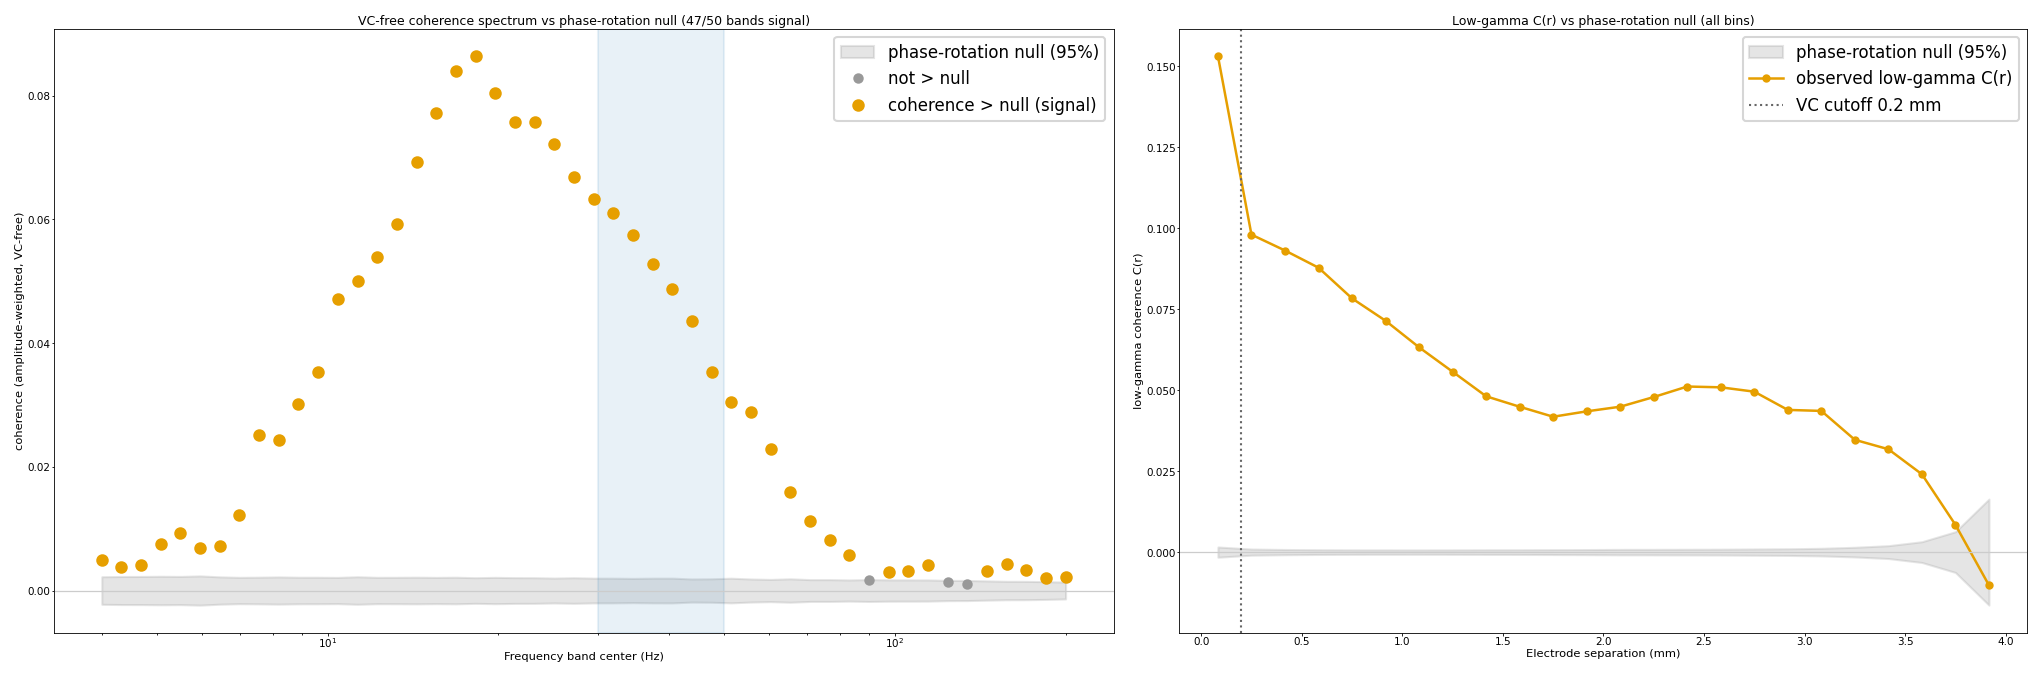

analytic phase-rotation null (28 events): 47/50 bands clear the chance floor over 0.2-4.0 mm; low-gamma obs coherence 0.0498 vs null 95% \u00b10.0020.


In [36]:
# --- Phase-rotation null (analytic): is the coherence LEVEL above chance? ---
# The coordinate-shuffle null only reshuffles distance labels, so it PRESERVES the coherence level and
# can't say whether there is genuine coherence at all. To test the level, rotate each channel's phasor by
# a random constant phase: every |z| (hence the denominator sqrt(P_i P_j)) is unchanged and only each pair's
# cross-spectrum spins by a random angle, so Re<z_i z_j*> has mean 0. Because two distinct pairs share at
# most one channel's phase (which then averages away), the pair contributions are uncorrelated and the null
# is ANALYTIC per distance bin: level 0, variance 0.5*Sum|cross_ij|^2 / (Sum sqrt(P_i P_j))^2 (Gaussian by
# CLT; matches a 400-rep Monte-Carlo to ~1%). No reps -> just one extra bincount of |cross|^2 on the cached
# diag_banks. The <DIAG_FIT_MIN_MM (volume-conduction) bins are computed too; the per-band spectrum is read
# off the >=DIAG_FIT_MIN_MM range only.
def _phaserot_stats(bank, edges):
    """Per event: observed C(r) plus the phase-rotation null's per-bin (0.5*Sum|cross|^2, Sum sqrt(P P))."""
    coords = np.asarray(bank["coords"], float); cm = bank["core_mask"]; N = coords.shape[0]; nbins = len(edges) - 1
    iu = np.triu_indices(N, 1); d = np.linalg.norm(coords[iu[0]] - coords[iu[1]], axis=1)
    inr = d <= edges[-1]; iu0, iu1 = iu[0][inr], iu[1][inr]
    bins = np.clip(np.digitize(d[inr], edges) - 1, 0, nbins - 1)
    counts = np.bincount(bins, minlength=nbins); mask = counts < DIAG_MIN_PAIRS
    nbands = bank["u"].shape[0]
    obs = np.full((nbands, nbins), np.nan); ss = np.zeros((nbands, nbins)); den = np.zeros((nbands, nbins))
    for bi in range(nbands):
        zc = (bank["u"][bi] * bank["amp"][bi])[cm]
        cross = zc.conj().T @ zc; p = np.sum(np.abs(zc) ** 2, axis=0)
        cp = cross[iu0, iu1]; den_p = np.sqrt(p[iu0] * p[iu1])
        num_b = np.bincount(bins, np.real(cp), minlength=nbins)
        den_b = np.bincount(bins, den_p, minlength=nbins)
        ss_b = 0.5 * np.bincount(bins, np.abs(cp) ** 2, minlength=nbins)      # 0.5*Sum|cross|^2 (null variance numerator)
        c = np.full(nbins, np.nan); np.divide(num_b, den_b, out=c, where=den_b > 0); c[mask] = np.nan
        obs[bi] = c; ss[bi] = ss_b; den[bi] = den_b
    return obs, ss, den

try:
    _rev = Parallel(n_jobs=-1)(delayed(_phaserot_stats)(b, diag_edges) for b in diag_banks)
except Exception as _e:
    print(f"parallel phase-rotation stats unavailable ({_e}); serial"); _rev = [_phaserot_stats(b, diag_edges) for b in diag_banks]
_obs = np.stack([o for o, _, _ in _rev]); _ss = np.stack([s for _, s, _ in _rev]); _dn = np.stack([d for _, _, d in _rev])
_n_ev = len(diag_banks)
_rot_obs = np.nanmean(_obs, axis=0)                                          # (nbands, nbins) observed C(r)
with np.errstate(divide="ignore", invalid="ignore"):
    _var_e = _ss / np.where(_dn > 0, _dn, np.nan) ** 2                       # per-event null variance per bin
_rot_std = np.sqrt(np.nansum(_var_e, axis=0)) / _n_ev                        # aggregate null std (mean 0)

_ctr = 0.5 * (diag_edges[:-1] + diag_edges[1:]); _fitm = (_ctr >= DIAG_FIT_MIN_MM) & (_ctr <= DIAG_FIT_MAX_MM)
_k = int(np.sum(_fitm))
_obs_spec = np.nanmean(_rot_obs[:, _fitm], axis=1)                           # VC-free coherence per band (>=DIAG_FIT_MIN_MM)
_spec_std = np.sqrt(np.nansum(_rot_std[:, _fitm] ** 2, axis=1)) / _k         # null std of the fit-range mean
_signal = _obs_spec > 1.96 * _spec_std
_lgm = (coh_band_centers >= DIAG_LOWGAMMA_HZ[0]) & (coh_band_centers <= DIAG_LOWGAMMA_HZ[1])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.4), constrained_layout=True, gridspec_kw={"width_ratios": [1.25, 1]})
axL.fill_between(coh_band_centers, -1.96 * _spec_std, 1.96 * _spec_std, color="0.6", alpha=0.25, label="phase-rotation null (95%)")
axL.plot(coh_band_centers[~_signal], _obs_spec[~_signal], "o", color="0.6", ms=4, label="not > null")
axL.plot(coh_band_centers[_signal], _obs_spec[_signal], "o", color=FIGURE3_ACCENT_COLOR, ms=5, label="coherence > null (signal)")
axL.axvspan(DIAG_LOWGAMMA_HZ[0], DIAG_LOWGAMMA_HZ[1], color=FIGURE3_BURST_COLOR, alpha=0.10)
axL.axhline(0, color="0.8", lw=0.6)
axL.set(xscale="log", xlabel="Frequency band center (Hz)", ylabel="coherence (amplitude-weighted, VC-free)",
        title=f"VC-free coherence spectrum vs phase-rotation null ({int(_signal.sum())}/{_signal.size} bands signal)")
axL.legend(fontsize=8)
_obs_lg = np.nanmean(_rot_obs[_lgm], axis=0); _std_lg = np.sqrt(np.nansum(_rot_std[_lgm] ** 2, axis=0)) / max(int(_lgm.sum()), 1)
axR.fill_between(_ctr, -1.96 * _std_lg, 1.96 * _std_lg, color="0.6", alpha=0.25, label="phase-rotation null (95%)")
axR.plot(_ctr, _obs_lg, "o-", color=FIGURE3_ACCENT_COLOR, ms=3, lw=1.2, label="observed low-gamma C(r)")
axR.axvline(DIAG_FIT_MIN_MM, color="0.4", ls=":", lw=1, label=f"VC cutoff {DIAG_FIT_MIN_MM} mm")
axR.axhline(0, color="0.8", lw=0.6)
axR.set(xlabel="Electrode separation (mm)", ylabel="low-gamma coherence C(r)", title="Low-gamma C(r) vs phase-rotation null (all bins)")
axR.legend(fontsize=8)
plt.show()
print(f"analytic phase-rotation null ({_n_ev} events): {int(_signal.sum())}/{_signal.size} bands clear the chance floor over "
      f"{DIAG_FIT_MIN_MM}-{DIAG_FIT_MAX_MM} mm; low-gamma obs coherence {np.nanmean(_obs_spec[_lgm]):.4f} "
      f"vs null 95% \\u00b1{1.96*np.nanmean(_spec_std[_lgm]):.4f}.")


## Beta vs low-gamma: coherence over distance + residual ripple
Compares beta (15–25 Hz) and low-gamma (30–50 Hz) amplitude-weighted C(r) with exp+cos fits, and the exponential-residual (cosine) ripple for each.

/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_71473/3858375233.py:12: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.nanmean(_maps2[:, m, :], axis=1), axis=0)


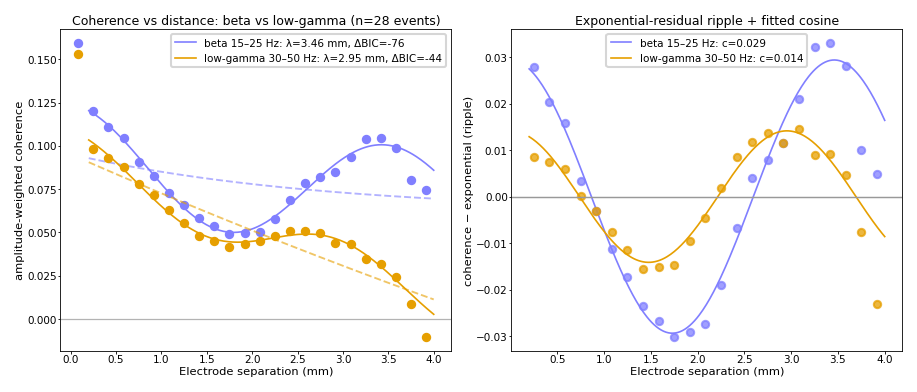

beta 15–25 Hz: wavelength 3.46 mm, exp+cos vs exp ΔBIC = -75.8
low-gamma 30–50 Hz: wavelength 2.95 mm, exp+cos vs exp ΔBIC = -44.3


In [40]:
# --- Beta vs low-gamma: coherence over distance + exponential-residual (cosine) ripple ---
# The heatmap shows a pronounced beta (15-25 Hz) peak alongside low-gamma (30-50 Hz). Here we compare the
# two bands directly: amplitude-weighted coherence C(r) with its exp+cos fit (left), and the residual after
# removing the exponential decay (right) -- the isolated cosine ripple whose wavelength the model predicts.
_b2 = [("beta 15–25 Hz", DIAG_BETA_HZ, FIGURE3_PRIMARY_COLOR), ("low-gamma 30–50 Hz", DIAG_LOWGAMMA_HZ, FIGURE3_ACCENT_COLOR)]
_db2 = distance_bins(diag_banks[0]["coords"], diag_edges); _ctr2 = _db2["centers"]; _cnt2 = _db2["counts"]
_fm2 = (_ctr2 >= DIAG_FIT_MIN_MM) & (_ctr2 <= DIAG_FIT_MAX_MM)
_maps2 = np.asarray([band_distance_map(b, distance_bins(b["coords"], diag_edges), weighting="coherency") for b in diag_banks])

def _cr_range(lo, hi):
    m = (coh_band_centers >= lo) & (coh_band_centers <= hi)
    return np.nanmean(np.nanmean(_maps2[:, m, :], axis=1), axis=0)

def _fit2(cr):
    m = np.isfinite(cr) & _fm2
    if m.sum() < 8:
        return None
    r, y, w = _ctr2[m], cr[m], np.maximum(_cnt2[m], 1e-9); sig = 1.0 / np.sqrt(w); wl_hi = DIAG_WL_CEILING_MM * 1.4
    try:
        pe, _ = curve_fit(_exp, r, y, p0=[max(y.max()-y.min(),1e-3),1.0,float(np.median(y))], sigma=sig, maxfev=40000, bounds=([0,.05,-1],[3,20,1]))
        pf, _ = curve_fit(_expcos, r, y, p0=[*pe,.03,min(2.3,wl_hi)], sigma=sig, maxfev=80000, bounds=([0,.05,-1,0,0.3],[3,20,1,1,wl_hi]))
    except Exception:
        return None
    rss_e = float(np.sum(w*(y-_exp(r,*pe))**2)); rss_f = float(np.sum(w*(y-_expcos(r,*pf))**2))
    return {"p_full": pf, "wavelength": float(pf[4]), "dbic": float(r.size*np.log(rss_f/rss_e) + 2*np.log(r.size))}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(6, 2.5), constrained_layout=True)
_rr = np.linspace(DIAG_FIT_MIN_MM, DIAG_FIT_MAX_MM, 300)
_summary = []
for lbl, (lo, hi), col in _b2:
    cr = _cr_range(lo, hi); fit = _fit2(cr)
    axL.plot(_ctr2, cr, "o", color=col, ms=3.5)
    if fit is not None:
        a, lam, b, c, wl = fit["p_full"]
        axL.plot(_rr, _expcos(_rr, *fit["p_full"]), "-", color=col, lw=0.8,
                 label=f"{lbl}: λ={wl:.2f} mm, ΔBIC={fit['dbic']:.0f}")
        axL.plot(_rr, a * np.exp(-_rr / lam) + b, "--", color=col, lw=0.9, alpha=0.6)
        resid = cr - (a * np.exp(-_ctr2 / lam) + b)
        axR.plot(_ctr2[_fm2], resid[_fm2], "o", color=col, ms=3.5, alpha=0.75)
        axR.plot(_rr, c * np.cos(2 * np.pi * _rr / wl), "-", color=col, lw=0.8, label=f"{lbl}: c={c:.3f}")
        _summary.append((lbl, wl, fit["dbic"]))
    else:
        axL.plot([], [], color=col, label=f"{lbl}: fit failed")
axL.axhline(0, color="0.7", lw=0.6)
axL.set(xlabel="Electrode separation (mm)", ylabel="amplitude-weighted coherence",
        title=f"Coherence vs distance: beta vs low-gamma (n={len(diag_banks)} events)")
axL.legend()
axR.axhline(0, color="0.6", lw=0.7)
axR.set(xlabel="Electrode separation (mm)", ylabel="coherence − exponential (ripple)",
        title="Exponential-residual ripple + fitted cosine")
axR.legend()
plt.show()
for lbl, wl, dbic in _summary:
    print(f"{lbl}: wavelength {wl:.2f} mm, exp+cos vs exp ΔBIC = {dbic:.1f}")
